<a href="https://colab.research.google.com/github/franklaercio/paul-the-octopus/blob/main/notebooks/paultheoctopus.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Paul The Octopus Machine Learning

Code by Frank Laércio, Software Developer at CI&T.<br>
frank.junior@ciandt.com [github.com/franklaercio](https://github.com/franklaercio)

![banner.png](https://drive.google.com/uc?export=view&id=1euYvRBbkQtYMslUTwaUUdgcGFc_1gupL)

**Content**
1.   Importing libraries and files for GCP
2.   Fifa World Cup Data Analyzing
3.   Historical Results
4.   Ranking Fifa
5.   Modeling Machine Learning for Fifa World Cup Predictions
6.   Qatar World Cup Predictions



## **Importing libraries and loading local data**

In this section we are import all libraries that need on this project.

*   Numpy for linear algebra
*   Pandas for manipuling data
*   Seaborn for data visualization
*   Matplotlib for data visualization



In [1]:
import os

# ============================================================================
# Configuracao central (P6 - higiene)
# ----------------------------------------------------------------------------
# Entradas ficam em `data/raw/` e artefatos gerados em `data/results/`.
# Os caminhos funcionam a partir da raiz ou de dentro de notebooks/.
# ============================================================================
DATA_ROOT = 'data' if os.path.isdir('data') else '../data'
RAW_DATA_DIR = os.path.join(DATA_ROOT, 'raw')
RESULTS_DIR = os.path.join(DATA_ROOT, 'results')
os.makedirs(RESULTS_DIR, exist_ok=True)

print('Configuracao P6: RAW_DATA_DIR =', RAW_DATA_DIR, '| RESULTS_DIR =', RESULTS_DIR)

Configuracao P6: RAW_DATA_DIR = data/raw | RESULTS_DIR = data/results


In [2]:
import numpy as np 
import pandas as pd
import re
import calendar
from datetime import datetime

import seaborn as sns
sns.set_theme(style="darkgrid")

import matplotlib.pyplot as plt

Os dados de entrada ficam em `data/raw/` e sao carregados via `RAW_DATA_DIR`, sem download externo. As saidas sao gravadas em `data/results/`.

## **Fifa World Cup Data Analyzing**

In this section, we understand our dataset and make some assumptions. Like a does the FIFA ranking influence the results, are the clashes in world cups important in today's results or the win set is an interesting data.

First, we need to import the entire dataset for some assumptions.

### **Historical Results**

This section is an important part of building the algorithm, as we will check the previous results of the selections in matches. But we will make the following refinements to the data:
*   Check match dates.
*   Select the most played tournaments, as they are the most disputed.
*   Remove friendlies, as they can negatively influence predictions, due to their competitiveness.
*   Remove matches older than the 21st century, as soccer is very current.


In [3]:
# Importing the matchs
df_historical_results = pd.read_csv(f'{RAW_DATA_DIR}/historical-results.csv')
df_historical_results.head()

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral
0,1872-11-30,Scotland,England,0,0,Friendly,Glasgow,Scotland,False
1,1873-03-08,England,Scotland,4,2,Friendly,London,England,False
2,1874-03-07,Scotland,England,2,1,Friendly,Glasgow,Scotland,False
3,1875-03-06,England,Scotland,2,2,Friendly,London,England,False
4,1876-03-04,Scotland,England,3,0,Friendly,Glasgow,Scotland,False


In [4]:
# Fixing the format date
for col in ['date']:
    df_historical_results[col] = pd.to_datetime(df_historical_results[col], format='%Y-%m-%d')

# Parsing the date to datetime
df_historical_results['date'] = pd.to_datetime(df_historical_results['date'])

In [5]:
# Checking if exists null rows
df_historical_results.isnull().sum()

date          0
home_team     0
away_team     0
home_score    0
away_score    0
tournament    0
city          0
country       0
neutral       0
dtype: int64

In [6]:
# Removing collumns not using in the model
# P3: NAO descartamos mais 'neutral'. Ela e necessaria para o Dixon-Coles:
# o mando de campo (gamma) so se aplica em jogos NAO-neutros, e a Copa e em
# campo neutro. 'neutral' nunca entra como feature dos classificadores (P1/P2);
# e usada apenas pelo modelo de gols (P3) para separar/zerar o mando.
df_historical_results = df_historical_results.drop (['city'], axis = 1)
df_historical_results = df_historical_results.drop (['country'], axis = 1)

<Axes: xlabel='count', ylabel='tournament'>

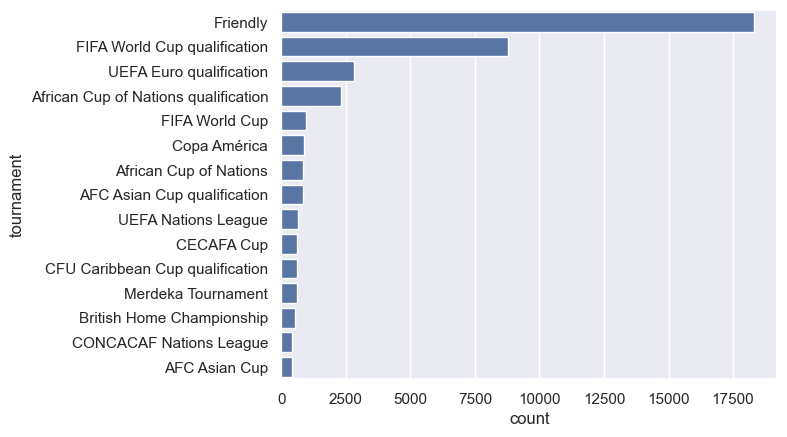

In [7]:
# Checking the 15 most tournaments
frequently_tournament = df_historical_results['tournament'].value_counts().nlargest(15)
sns.barplot(x=frequently_tournament, y=frequently_tournament.index)

In [8]:
# Removing the least played tournaments by teams. 
df_historical_results = df_historical_results[df_historical_results["tournament"].isin(frequently_tournament.index)]
df_historical_results.head()

,date,home_team,away_team,home_score,away_score,tournament,neutral
0,1872-11-30,Scotland,England,0,0,Friendly,False
1,1873-03-08,England,Scotland,4,2,Friendly,False
2,1874-03-07,Scotland,England,2,1,Friendly,False
3,1875-03-06,England,Scotland,2,2,Friendly,False
4,1876-03-04,Scotland,England,3,0,Friendly,False


<Axes: xlabel='count', ylabel='tournament'>

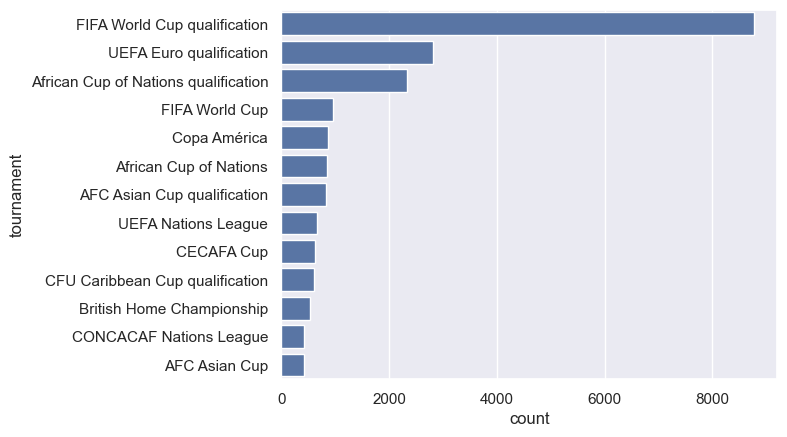

In [9]:
# Removing the follow tournaments: Friendly, British Championship and Merdeka Tournament
df_historical_results.drop(df_historical_results.index[(df_historical_results['tournament'] == 'Friendly')],axis=0,inplace=True)
df_historical_results.drop(df_historical_results.index[(df_historical_results['tournament'] == 'British Championship')],axis=0,inplace=True)
df_historical_results.drop(df_historical_results.index[(df_historical_results['tournament'] == 'Merdeka Tournament')],axis=0,inplace=True)

frequently_tournament = df_historical_results['tournament'].value_counts()
sns.barplot(x=frequently_tournament, y=frequently_tournament.index)

In [10]:
# Filtro de data (P6 - documentado): mantem apenas partidas do seculo XXI.
# `~(date <= '2000-01-01')` exclui tudo ATE e INCLUSIVE 2000-01-01; como nao ha
# jogo exatamente nessa data, equivale a manter `date > 2000-01-01` (futebol moderno).
# Obs.: o filtro analogo do ranking usa `< '2000-01-01'` (estritamente menor) -- mesma
# intencao, mantendo coerencia entre resultados e ranking.
df_historical_results = df_historical_results[~(df_historical_results['date'] <= '2000-01-01')]
df_historical_results.head()

,date,home_team,away_team,home_score,away_score,tournament,neutral
24082,2000-01-22,Ghana,Cameroon,1,1,African Cup of Nations,False
24083,2000-01-23,China PR,Philippines,8,0,AFC Asian Cup qualification,True
24084,2000-01-23,Egypt,Zambia,2,0,African Cup of Nations,True
24086,2000-01-23,Nigeria,Tunisia,4,2,African Cup of Nations,False
24087,2000-01-23,South Africa,Gabon,3,1,African Cup of Nations,True


In [11]:
# Checking the null values
df_historical_results.isnull().sum()

date          0
home_team     0
away_team     0
home_score    0
away_score    0
tournament    0
neutral       0
dtype: int64

In [12]:
# Changing the tournaments identifier
tornaments_names = {"FIFA World Cup qualification": 0, "UEFA Euro qualification": 1, "African Cup of Nations qualification": 2, "FIFA World Cup": 3, "Copa América": 4, "AFC Asian Cup qualification": 5, "African Cup of Nations": 6, "CECAFA Cup": 7, "CFU Caribbean Cup qualification": 8, "UEFA Nations League": 9, "Gulf Cup": 10, "AFC Asian Cup":11}

df_historical_results = df_historical_results.replace({"tournament": tornaments_names})

df_historical_results.head()

,date,home_team,away_team,home_score,away_score,tournament,neutral
24082,2000-01-22,Ghana,Cameroon,1,1,6,False
24083,2000-01-23,China PR,Philippines,8,0,5,True
24084,2000-01-23,Egypt,Zambia,2,0,6,True
24086,2000-01-23,Nigeria,Tunisia,4,2,6,False
24087,2000-01-23,South Africa,Gabon,3,1,6,True


Interesting, there is no null field in the dataset, so it will not be necessary to adjust the dataset to such values.

### **Ranking Fifa**

In this section we will check the Fifa ranking for each team. This step will be important for determining the algorithm, as the FIFA ranking makes a calculation to rank the strongest teams.

In [13]:
# Importing the ranking data to the notebook
df_ranking = pd.read_csv(f'{RAW_DATA_DIR}/ranking.csv')
df_ranking.head()

,rank,country_full,country_abrv,total_points,previous_points,rank_change,confederation,rank_date
0,1.0,Germany,GER,57.0,0.0,0,UEFA,1992-12-31
1,96.0,Syria,SYR,11.0,0.0,0,AFC,1992-12-31
2,97.0,Burkina Faso,BFA,11.0,0.0,0,CAF,1992-12-31
3,99.0,Latvia,LVA,10.0,0.0,0,UEFA,1992-12-31
4,100.0,Burundi,BDI,10.0,0.0,0,CAF,1992-12-31


In [14]:
# Removing collumns not using in the model
df_ranking = df_ranking.drop (['confederation'], axis = 1)
df_ranking = df_ranking.drop (['country_abrv'], axis = 1)
df_ranking = df_ranking.drop (['previous_points'], axis = 1)
df_ranking = df_ranking.drop (['rank_change'], axis = 1)

# Removing ranks before 00s
df_ranking = df_ranking[~(df_ranking['rank_date'] < '2000-01-01')]
df_ranking['rank_date'] = pd.to_datetime(df_ranking['rank_date'])

df_ranking.head()

,rank,country_full,total_points,rank_date
12119,136.0,Bahrain,223.0,2000-01-19
12120,135.0,Fiji,227.0,2000-01-19
12121,134.0,Madagascar,231.0,2000-01-19
12122,129.0,Eswatini,253.0,2000-01-19
12123,132.0,Sudan,244.0,2000-01-19


This part of the merge was inspired by the [Soccer World Cup 2018 Winner](https://www.kaggle.com/code/agostontorok/soccer-world-cup-2018-winner).

In [15]:
# Setting index by rank_date
df_ranking = df_ranking.set_index(['rank_date'])\
            .groupby(['country_full'])\
            .resample('D').first()\
            .ffill()\
            .reset_index()

# Merge the match data with ranking data
df_historical_results = df_historical_results.merge(df_ranking, left_on=['date', 'home_team'], right_on=['rank_date', 'country_full'])
df_historical_results = df_historical_results.merge(df_ranking, left_on=['date', 'away_team'], right_on=['rank_date', 'country_full'], suffixes=('_home', '_away'))

In [16]:
# Deliting some collums that we don't need
df_historical_results = df_historical_results.drop (['country_full_home'], axis = 1)
df_historical_results = df_historical_results.drop (['country_full_away'], axis = 1)
# P4: NAO descartamos mais 'total_points_home'/'total_points_away'. A pontuacao
# FIFA continua (total_points) e mais informativa que a posicao ordinal (rank);
# entra como feature do P4 (points_diff). Como o merge (cell-25) e por 'date',
# total_points e o ranking VIGENTE na data da partida -> estritamente pre-partida.
df_historical_results = df_historical_results.drop (['rank_date_away'], axis = 1)
df_historical_results = df_historical_results.drop (['rank_date_home'], axis = 1)
# P1: NAO descartamos mais 'date' aqui. Ela e necessaria para o split temporal
# honesto (treino ate 2018, validacao 2019-2021, hold-out Copa 2022).
# 'date' nunca entra como feature do modelo (ver celulas de modelagem).

In [17]:
# Checking the data frame of machs
df_historical_results.head()

,date,home_team,away_team,home_score,away_score,tournament,neutral,rank_home,total_points_home,rank_away,total_points_away
0,2000-01-22,Ghana,Cameroon,1,1,6,False,50.0,526.0,57.0,501.0
1,2000-01-23,China PR,Philippines,8,0,5,True,88.0,412.0,181.0,75.0
2,2000-01-23,Egypt,Zambia,2,0,6,True,38.0,558.0,36.0,571.0
3,2000-01-23,Nigeria,Tunisia,4,2,6,False,76.0,444.0,28.0,604.0
4,2000-01-23,South Africa,Gabon,3,1,6,True,31.0,597.0,72.0,456.0


In [18]:
# Calculing the rank_difference, average_rank, score_difference nad is_won
df_historical_results['rank_difference'] = df_historical_results['rank_home'] - df_historical_results['rank_away']
df_historical_results['average_rank'] = (df_historical_results['rank_home'] + df_historical_results['rank_away'])/2
df_historical_results['score_difference'] = df_historical_results['home_score'] - df_historical_results['away_score']
df_historical_results['is_won'] = df_historical_results['score_difference'] > 0

# P1: alvo de 3 classes (1X2) usado APENAS para a avaliacao honesta (RPS/log-loss/Brier
# e baselines). O modelo atual continua binario (is_won); o alvo multiclasse e P2.
# Ordem fixada: 0 = home_win, 1 = draw, 2 = away_win.
def outcome_1x2(row):
    if row['home_score'] > row['away_score']:
        return 0  # home_win
    if row['home_score'] < row['away_score']:
        return 2  # away_win
    return 1      # draw

df_historical_results['outcome'] = df_historical_results.apply(outcome_1x2, axis=1)

In [19]:
# Checking the data frame of machs
df_historical_results.head()

,date,home_team,away_team,home_score,away_score,tournament,neutral,rank_home,total_points_home,rank_away,total_points_away,rank_difference,average_rank,score_difference,is_won,outcome
0,2000-01-22,Ghana,Cameroon,1,1,6,False,50.0,526.0,57.0,501.0,-7.0,53.5,0,False,1
1,2000-01-23,China PR,Philippines,8,0,5,True,88.0,412.0,181.0,75.0,-93.0,134.5,8,True,0
2,2000-01-23,Egypt,Zambia,2,0,6,True,38.0,558.0,36.0,571.0,2.0,37.0,2,True,0
3,2000-01-23,Nigeria,Tunisia,4,2,6,False,76.0,444.0,28.0,604.0,48.0,52.0,2,True,0
4,2000-01-23,South Africa,Gabon,3,1,6,True,31.0,597.0,72.0,456.0,-41.0,51.5,2,True,0


## **Modeling Machine Learning for Fifa World Cup Predictions**

In this section we will make the predictions after organizing the data previously done. For this, we will use the decision tree technique and a regression forest. These are algorithms provided by the sklearn library. <br>
Para fazer o aprendizado iremos utilizar os dados da diferença de ranks e a média do rank. In addition, to verify the effectiveness of the algorithm, we will use the data of who won or lost the match.


In [20]:
# Predict target
X, y, X_test = df_historical_results.loc[:,['average_rank', 'rank_difference']], df_historical_results['is_won'], df_historical_results.loc[:,['average_rank', 'rank_difference']]

# Importing all the libraries we need
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import RandomForestClassifier

# Random Forest Classification Algorithm
random_forest = RandomForestClassifier(n_estimators=100)
random_forest.fit(X, y)

# Make a prediction
Y_prediction = random_forest.predict(X_test)

# Checking accuracy
random_forest.score(X, y)
acc_random_forest = round(random_forest.score(X, y) * 100, 2)

print("Accuracy Random Forest: ", acc_random_forest)

Accuracy Random Forest:  93.27


## **P1 — Avaliação honesta (split temporal + métricas + baselines)**

A acurácia de **94,24%** reportada acima é uma ilusão: a célula anterior treina e mede no **mesmo conjunto** (`X_test = X`). Em futebol de seleções esse número é irreal — o alvo binário `is_won` ainda ignora os empates (~22% dos jogos).

Esta seção implementa a fundação de avaliação que todas as etapas seguintes vão reutilizar:

1. **Métricas próprias** de probabilidade: RPS (Ranked Probability Score), log-loss e Brier multiclasse, além de um reliability diagram.
2. **Split temporal walk-forward** (sem embaralhar): treino até 2018, validação 2019–2021, **hold-out = Copa 2022**.
3. **Baselines** honestos (B0 frequência-base, B1 favorito do ranking; B2 Elo fica para o P4).
4. **Re-medição honesta** do modelo atual no hold-out — substitui o 94% pelo número real.

> A ordem das classes 1X2 é fixada como **0 = home_win, 1 = draw, 2 = away_win** (mando à esquerda, empate no meio, fora à direita) — o RPS exige uma ordem coerente entre vitória, empate e derrota.

In [21]:
# =====================================================================
# P1.1 - Celula utilitaria de metricas (reutilizavel pelas etapas futuras)
# Convencao: probs = matriz Nx3 de probabilidades (cada linha soma ~1),
#            outcomes = vetor de N rotulos inteiros {0=home_win, 1=draw, 2=away_win}.
# =====================================================================
from sklearn.metrics import log_loss as sk_log_loss


def _one_hot(outcomes, n_classes=3):
    """Converte rotulos inteiros em matriz one-hot Nxk."""
    outcomes = np.asarray(outcomes, dtype=int)
    oh = np.zeros((len(outcomes), n_classes))
    oh[np.arange(len(outcomes)), outcomes] = 1.0
    return oh


def ranked_probability_score(probs, outcomes):
    """RPS multiclasse (Ranked Probability Score).

    Entrada:
        probs    : matriz Nx3 de probabilidades na ordem [home_win, draw, away_win].
        outcomes : vetor de N rotulos inteiros (0/1/2) na mesma ordem.
    Saida:
        float - RPS medio (quanto MENOR, melhor). Respeita a ordem dos
        resultados: soma das diferencas quadraticas entre as CDFs cumulativas
        de previsao e observacao, normalizada por (k-1). E a metrica
        padrao-ouro para previsao 1X2 porque penaliza menos um erro
        "vizinho" (prever vitoria e dar empate) do que um erro "distante"
        (prever vitoria e dar derrota).
    """
    probs = np.asarray(probs, dtype=float)
    outcomes = np.asarray(outcomes, dtype=int)
    n, k = probs.shape
    cdf_pred = np.cumsum(probs, axis=1)
    cdf_obs = np.cumsum(_one_hot(outcomes, k), axis=1)
    return float(np.mean(np.sum((cdf_pred - cdf_obs) ** 2, axis=1) / (k - 1)))


def multiclass_brier(probs, outcomes):
    """Brier score multiclasse = media do erro quadratico contra o one-hot.

    Entrada: probs Nx3, outcomes N. Saida: float (menor = melhor)."""
    probs = np.asarray(probs, dtype=float)
    oh = _one_hot(outcomes, probs.shape[1])
    return float(np.mean(np.sum((probs - oh) ** 2, axis=1)))


def multiclass_log_loss(probs, outcomes):
    """Log-loss multiclasse (via sklearn). Penaliza overconfidence.

    Entrada: probs Nx3, outcomes N. Saida: float (menor = melhor)."""
    return float(sk_log_loss(np.asarray(outcomes, int), probs, labels=[0, 1, 2]))


def accuracy_1x2(probs, outcomes):
    """Acerto de resultado 1X2 = argmax da probabilidade == rotulo observado."""
    return float(np.mean(np.argmax(np.asarray(probs), axis=1) == np.asarray(outcomes, int)))


def evaluate_probs(name, probs, outcomes):
    """Avalia um conjunto de probabilidades 1X2 e imprime/retorna as metricas.

    Funcao central pedida no criterio de aceitacao do P1: recebe as
    probabilidades de um modelo/baseline + os resultados reais e devolve
    RPS, log-loss e Brier (alem de acerto de resultado)."""
    res = {
        "model": name,
        "RPS": ranked_probability_score(probs, outcomes),
        "log_loss": multiclass_log_loss(probs, outcomes),
        "Brier": multiclass_brier(probs, outcomes),
        "acc_1x2": accuracy_1x2(probs, outcomes),
    }
    print("  %-26s RPS=%.4f  log_loss=%.4f  Brier=%.4f  acc1X2=%.3f"
          % (name, res["RPS"], res["log_loss"], res["Brier"], res["acc_1x2"]))
    return res


def reliability_diagram(probs, outcomes, class_idx=0, n_bins=10, title=None):
    """Reliability diagram (curva de calibracao) para uma classe 1X2.

    Entrada:
        probs     : matriz Nx3.
        outcomes  : vetor N de rotulos {0,1,2}.
        class_idx : qual classe avaliar (0=home_win, 1=draw, 2=away_win).
    Saida: plota a curva (probabilidade prevista x frequencia observada).
    Uma probabilidade honesta cai sobre a diagonal."""
    probs = np.asarray(probs, float)
    p = probs[:, class_idx]
    y = (np.asarray(outcomes, int) == class_idx).astype(float)
    bins = np.linspace(0, 1, n_bins + 1)
    idx = np.digitize(p, bins) - 1
    idx = np.clip(idx, 0, n_bins - 1)
    xs, ys = [], []
    for b in range(n_bins):
        mask = idx == b
        if mask.sum() > 0:
            xs.append(p[mask].mean())
            ys.append(y[mask].mean())
    plt.figure(figsize=(5, 5))
    plt.plot([0, 1], [0, 1], 'k--', label='calibracao perfeita')
    plt.plot(xs, ys, 'o-', label='modelo')
    plt.xlabel('Probabilidade prevista')
    plt.ylabel('Frequencia observada')
    plt.title(title or ('Reliability diagram - classe %d' % class_idx))
    plt.legend()
    plt.show()


print("Funcoes de metrica P1 carregadas: ranked_probability_score, multiclass_brier, "
      "multiclass_log_loss, evaluate_probs, reliability_diagram")

Funcoes de metrica P1 carregadas: ranked_probability_score, multiclass_brier, multiclass_log_loss, evaluate_probs, reliability_diagram


In [22]:
# =====================================================================
# P1.2 - Split temporal walk-forward (SEM embaralhar - respeita a ordem do tempo)
#   Treino   : ate 2018-12-31
#   Validacao: 2019-01-01 a 2021-12-31  (tuning/calibracao nas etapas futuras)
#   Hold-out : Copa do Mundo 2022 (tournament == 3 e ano == 2022)
# A 'date' so e usada para o split; NUNCA entra como feature.
# =====================================================================
df_model = df_historical_results.sort_values('date').reset_index(drop=True)

train_set = df_model[df_model['date'] <= '2018-12-31']
valid_set = df_model[(df_model['date'] >= '2019-01-01') & (df_model['date'] <= '2021-12-31')]
# Hold-out = Copa 2022 inteira (FIFA World Cup tem id 3 em cell-19)
holdout_set = df_model[(df_model['date'].dt.year == 2022) & (df_model['tournament'] == 3)]

print("Distribuicao 1X2 (home/draw/away) no dataset completo:")
_dist = df_model['outcome'].value_counts(normalize=True).sort_index()
print("  %.3f / %.3f / %.3f" % (_dist.get(0, 0), _dist.get(1, 0), _dist.get(2, 0)))

print("\nTamanhos do split temporal:")
print("  Treino   (<= 2018-12-31)      : %d jogos" % len(train_set))
print("  Validacao(2019-01 a 2021-12)  : %d jogos" % len(valid_set))
print("  Hold-out (Copa 2022)          : %d jogos" % len(holdout_set))
print("  Empates no hold-out 2022      : %d de %d"
      % ((holdout_set['outcome'] == 1).sum(), len(holdout_set)))

Distribuicao 1X2 (home/draw/away) no dataset completo:
  0.487 / 0.217 / 0.295

Tamanhos do split temporal:
  Treino   (<= 2018-12-31)      : 7532 jogos
  Validacao(2019-01 a 2021-12)  : 1560 jogos
  Hold-out (Copa 2022)          : 57 jogos
  Empates no hold-out 2022      : 14 de 57


In [23]:
# =====================================================================
# P1.3 - Baselines (comparacao honesta) avaliados no hold-out 2022
#   B0: frequencia-base fixa do TREINO (mesma prob. para todo jogo).
#   B1: "favorito do ranking sempre vence" - versao suavizada 0.70/0.15/0.15
#       a favor do favorito (rank menor = melhor). A suavizacao evita que o
#       log-loss exploda quando o favorito nao vence (prob 0 num evento que
#       ocorreu => log-loss infinito). 0.70 reflete uma confianca alta porem
#       honesta; o resto e dividido entre empate e a zebra.
#   B2: Elo - NAO implementado aqui. Entra no P4 (placeholder abaixo).
# =====================================================================
y_holdout = holdout_set['outcome'].values

# --- B0: frequencia-base do treino ---
_base = train_set['outcome'].value_counts(normalize=True).sort_index()
b0_vec = np.array([_base.get(0, 0.0), _base.get(1, 0.0), _base.get(2, 0.0)])
b0_probs = np.tile(b0_vec, (len(holdout_set), 1))
print("B0 frequencia-base (treino) home/draw/away = %.3f / %.3f / %.3f\n" % tuple(b0_vec))

# --- B1: favorito do ranking (suavizado) ---
def b1_row(rank_home, rank_away):
    if rank_home < rank_away:      # mandante e favorito
        return [0.70, 0.15, 0.15]
    if rank_home > rank_away:      # visitante e favorito
        return [0.15, 0.15, 0.70]
    return [0.40, 0.20, 0.40]      # ranks iguais (raro): empate no meio

b1_probs = np.array([b1_row(r.rank_home, r.rank_away)
                     for r in holdout_set.itertuples(index=False)])

# --- B2: Elo (placeholder) ---
# B2 (probabilidades de Elo puro convertidas em 1X2) sera implementado no P4,
# quando o rating Elo incremental existir. Mantido fora do escopo do P1.
# b2_probs = elo_to_1x2(holdout_set)   # TODO P4

print("Baselines prontos: B0 (freq-base) e B1 (favorito do ranking). B2 (Elo) -> P4.")

B0 frequencia-base (treino) home/draw/away = 0.499 / 0.214 / 0.287

Baselines prontos: B0 (freq-base) e B1 (favorito do ranking). B2 (Elo) -> P4.


In [24]:
# =====================================================================
# P1.4 - Re-medicao HONESTA do modelo atual (RandomForest binario)
#   - Treinado SO no conjunto de treino temporal (<= 2018).
#   - Avaliado no hold-out 2022 (jamais visto no treino).
#   - Features continuam apenas average_rank e rank_difference (P1 nao
#     adiciona features). score_difference/home_score/away_score/is_won
#     NUNCA entram em X (sao alvo/vazamento).
# =====================================================================
FEATURES = ['average_rank', 'rank_difference']

rf_honest = RandomForestClassifier(n_estimators=100, random_state=42)
rf_honest.fit(train_set[FEATURES], train_set['is_won'])

# (1) Acuracia binaria honesta no hold-out 2022
acc_bin_holdout = rf_honest.score(holdout_set[FEATURES], holdout_set['is_won'])

# (2) Referencia: acuracia binaria in-sample (como o notebook faz hoje no
#     dataset inteiro) - so para evidenciar o tamanho da ilusao.
rf_insample = RandomForestClassifier(n_estimators=100, random_state=42)
rf_insample.fit(df_model[FEATURES], df_model['is_won'])
acc_bin_insample = rf_insample.score(df_model[FEATURES], df_model['is_won'])

print("Acuracia binaria in-sample (ilusao do notebook): %.4f" % acc_bin_insample)
print("Acuracia binaria HONESTA no hold-out 2022:       %.4f" % acc_bin_holdout)

# (3) Conversao honesta do modelo binario em pseudo-3-classes para o RPS/1X2:
#     p_home = predict_proba da classe positiva (is_won == True);
#     p_draw = 0  -> o modelo binario e ESTRUTURALMENTE incapaz de prever
#                    empate (motivacao direta do P2);
#     p_away = 1 - p_home.
pos_idx = list(rf_honest.classes_).index(True)
p_home = rf_honest.predict_proba(holdout_set[FEATURES])[:, pos_idx]
rf_probs = np.column_stack([p_home, np.zeros_like(p_home), 1.0 - p_home])

# Clip minimo para o log-loss nao explodir nos empates (p_draw == 0 em jogo
# que terminou empatado => log-loss infinito). Renormaliza para somar 1.
rf_probs_eval = np.clip(rf_probs, 1e-15, 1.0)
rf_probs_eval = rf_probs_eval / rf_probs_eval.sum(axis=1, keepdims=True)

print("\n=== Hold-out 2022 (Copa do Mundo) - metricas 1X2 ===")
results_table = [
    evaluate_probs("Modelo atual (RF binario)", rf_probs_eval, y_holdout),
    evaluate_probs("B0 frequencia-base", b0_probs, y_holdout),
    evaluate_probs("B1 favorito do ranking", b1_probs, y_holdout),
]

print("\nLeitura: o RF binario tem o PIOR RPS/log-loss/Brier do conjunto - ele")
print("nunca atribui probabilidade ao empate (p_draw=0), entao perde feio nos")
print("~25% de jogos que empatam. Ate o baseline trivial B0 o supera. Isso")
print("motiva diretamente o P2 (alvo de 3 classes).")

Acuracia binaria in-sample (ilusao do notebook): 0.9327
Acuracia binaria HONESTA no hold-out 2022:       0.5789

=== Hold-out 2022 (Copa do Mundo) - metricas 1X2 ===
  Modelo atual (RF binario)  RPS=0.3388  log_loss=9.2124  Brier=0.9233  acc1X2=0.421
  B0 frequencia-base         RPS=0.2334  log_loss=1.0777  Brier=0.6530  acc1X2=0.439
  B1 favorito do ranking     RPS=0.2019  log_loss=1.0053  Brier=0.5982  acc1X2=0.579

Leitura: o RF binario tem o PIOR RPS/log-loss/Brier do conjunto - ele
nunca atribui probabilidade ao empate (p_draw=0), entao perde feio nos
~25% de jogos que empatam. Ate o baseline trivial B0 o supera. Isso
motiva diretamente o P2 (alvo de 3 classes).


## **P2 — Alvo multiclasse {vitória, empate, derrota}**

O modelo binário do P1 (`is_won = score_difference > 0`) é **estruturalmente incapaz de prever empate**: empate e derrota caem na mesma classe `False`, então `p_draw = 0` sempre. Isso custa os ~22% de jogos que terminam empatados e, como o P1 mediu, faz o RandomForest binário ter o **pior** RPS/log-loss/Brier do conjunto — até o baseline trivial B0 o supera.

O P2 troca o alvo binário por **3 classes** (`outcome` 0/1/2, ordem `home_win` / `draw` / `away_win`, a mesma já criada em `cell-28` para a avaliação do P1) e treina classificadores **multiclasse** com `predict_proba` nas 3 colunas:

1. **Regressão logística multinomial** (referência: rápida, interpretável e bem calibrada).
2. **Gradient Boosting** (comparação não-linear).
3. **RandomForest multiclasse** (comparação com o modelo de origem do projeto).

Cuidados:

- **Sem vazamento de feature:** `X` continua sendo só `['average_rank', 'rank_difference']`. `score_difference`, `home_score`, `away_score`, `is_won` e `outcome` **nunca** entram em `X` — são o alvo. (Este cuidado fica crítico ao adicionar features no P4.)
- **Mesma infraestrutura do P1:** reaproveitamos `evaluate_probs`, `ranked_probability_score`, `reliability_diagram`, o split temporal (`train_set`/`holdout_set`) e os baselines `b0_probs`/`b1_probs`. Nada é recriado.
- **Ordem das classes:** as probabilidades são sempre reordenadas para `[p_home, p_draw, p_away]` (via `classes_`), independentemente da ordem interna do classificador — o RPS exige essa ordem coerente.

> Critério de aceitação: as 3 probabilidades somam 1, o RPS no hold-out 2022 melhora vs. o binário convertido, e o modelo prevê empate em proporção plausível (massa de probabilidade no empate ≈ taxa observada, nem 0% nem 50%).

In [25]:
# =====================================================================
# P2.1 - Treino dos classificadores MULTICLASSE (alvo de 3 classes 'outcome')
#   Alvo: df_historical_results['outcome']  (0=home_win, 1=draw, 2=away_win),
#         criado em cell-28. Treinamos SO no train_set temporal (<= 2018).
#   Features: as mesmas 2 do P1 (sem vazamento - score/home_score/away_score
#             NAO entram). A engenharia de features fica para o P4.
# =====================================================================
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

# FEATURES ja foi definido no P1.4 (= ['average_rank', 'rank_difference']).
# Guarda explicita anti-vazamento: nenhuma coluna de placar/alvo em FEATURES.
_proibidas = {'home_score', 'away_score', 'score_difference', 'is_won', 'outcome'}
assert not (_proibidas & set(FEATURES)), "Vazamento: feature de alvo/placar em X!"

X_train_mc = train_set[FEATURES]
y_train_mc = train_set['outcome']        # 3 classes
X_holdout_mc = holdout_set[FEATURES]


def proba_1x2(clf, X):
    """predict_proba reordenado para a ordem fixa [home_win, draw, away_win].

    Classificadores do sklearn ordenam as colunas por clf.classes_; aqui
    remapeamos cada coluna para o indice 0/1/2 correto. Garante que o RPS e
    os baselines comparem sempre a MESMA ordem de classes. Saida: Nx3 que
    soma 1 por linha."""
    pp = clf.predict_proba(X)
    out = np.zeros((len(X), 3))
    for col, cls in enumerate(clf.classes_):
        out[:, int(cls)] = pp[:, col]
    return out


# (1) Regressao logistica MULTINOMIAL - referencia (rapida, calibravel).
#     StandardScaler porque as 2 features tem escalas diferentes (rank medio
#     ~0-200 vs. diferenca de rank ~-200..200) e a regularizacao L2 do
#     LogisticRegression e sensivel a escala.
clf_logreg = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=1000, random_state=42),
)
clf_logreg.fit(X_train_mc, y_train_mc)

# (2) Gradient Boosting - comparacao nao-linear.
clf_gb = GradientBoostingClassifier(random_state=42)
clf_gb.fit(X_train_mc, y_train_mc)

# (3) RandomForest MULTICLASSE - comparacao com o modelo de origem do projeto.
clf_rf_mc = RandomForestClassifier(n_estimators=100, random_state=42)
clf_rf_mc.fit(X_train_mc, y_train_mc)

# Sanity check: as 3 probabilidades somam 1 (criterio de aceitacao do P2).
_p = proba_1x2(clf_logreg, X_holdout_mc)
print("LogReg multinomial: shape %s, soma por linha (min/max) = %.6f / %.6f"
      % (_p.shape, _p.sum(axis=1).min(), _p.sum(axis=1).max()))
print("Classes treinadas (logreg/gb/rf):",
      clf_logreg.classes_, clf_gb.classes_, clf_rf_mc.classes_)
print("Distribuicao do alvo no treino (0/1/2):",
      y_train_mc.value_counts(normalize=True).sort_index().round(3).to_dict())

LogReg multinomial: shape (57, 3), soma por linha (min/max) = 1.000000 / 1.000000
Classes treinadas (logreg/gb/rf): [0 1 2] [0 1 2] [0 1 2]
Distribuicao do alvo no treino (0/1/2): {0: 0.499, 1: 0.214, 2: 0.287}


In [26]:
# =====================================================================
# P2.2 - Avaliacao no hold-out 2022 vs. o binario do P1 e os baselines
#   Reusa evaluate_probs / ranked_probability_score do P1 (cell-33) e os
#   baselines b0_probs / b1_probs (cell-35), alem do rf_probs_eval (binario
#   convertido, cell-36). Menor RPS/log-loss/Brier = melhor.
# =====================================================================
logreg_probs = proba_1x2(clf_logreg, X_holdout_mc)
gb_probs     = proba_1x2(clf_gb,     X_holdout_mc)
rf_mc_probs  = proba_1x2(clf_rf_mc,  X_holdout_mc)

print("=== Hold-out 2022 (Copa do Mundo) - metricas 1X2 ===")
p2_results = [
    evaluate_probs("Modelo P1 (RF binario)",     rf_probs_eval, y_holdout),  # linha de base a bater
    evaluate_probs("B0 frequencia-base",          b0_probs,      y_holdout),
    evaluate_probs("B1 favorito do ranking",      b1_probs,      y_holdout),
    evaluate_probs("P2 LogReg multinomial",       logreg_probs,  y_holdout),
    evaluate_probs("P2 GradientBoosting",         gb_probs,      y_holdout),
    evaluate_probs("P2 RandomForest multiclasse", rf_mc_probs,   y_holdout),
]

# Massa de probabilidade media no empate (criterio: nem 0%, nem 50%).
print("\nProporcao de empate prevista (massa media de p_draw no hold-out):")
for name, P in [("LogReg", logreg_probs), ("GradBoost", gb_probs), ("RF-mc", rf_mc_probs)]:
    print("  %-10s p_draw medio = %.1f%%  (faixa %.1f%%-%.1f%%)"
          % (name, 100 * P[:, 1].mean(), 100 * P[:, 1].min(), 100 * P[:, 1].max()))
print("  Empates REAIS no hold-out 2022: %d de %d = %.1f%%"
      % ((y_holdout == 1).sum(), len(y_holdout), 100 * (y_holdout == 1).mean()))

# Escolhe o melhor modelo multiclasse pelo RPS (metrica padrao-ouro 1X2).
_p2_only = [r for r in p2_results if r["model"].startswith("P2")]
best = min(_p2_only, key=lambda r: r["RPS"])
clf_multiclass = {"P2 LogReg multinomial": clf_logreg,
                  "P2 GradientBoosting": clf_gb,
                  "P2 RandomForest multiclasse": clf_rf_mc}[best["model"]]
print("\nMelhor modelo multiclasse pelo RPS: %s (RPS=%.4f)" % (best["model"], best["RPS"]))
print("=> 'clf_multiclass' sera usado na inferencia da Copa (cell-43).")

=== Hold-out 2022 (Copa do Mundo) - metricas 1X2 ===
  Modelo P1 (RF binario)     RPS=0.3388  log_loss=9.2124  Brier=0.9233  acc1X2=0.421
  B0 frequencia-base         RPS=0.2334  log_loss=1.0777  Brier=0.6530  acc1X2=0.439
  B1 favorito do ranking     RPS=0.2019  log_loss=1.0053  Brier=0.5982  acc1X2=0.579
  P2 LogReg multinomial      RPS=0.2072  log_loss=1.0047  Brier=0.5972  acc1X2=0.491
  P2 GradientBoosting        RPS=0.2086  log_loss=1.0090  Brier=0.6016  acc1X2=0.474
  P2 RandomForest multiclasse RPS=0.2985  log_loss=2.5252  Brier=0.8115  acc1X2=0.404

Proporcao de empate prevista (massa media de p_draw no hold-out):
  LogReg     p_draw medio = 28.5%  (faixa 18.8%-31.8%)
  GradBoost  p_draw medio = 25.5%  (faixa 14.1%-40.0%)
  RF-mc      p_draw medio = 22.6%  (faixa 0.0%-84.0%)
  Empates REAIS no hold-out 2022: 14 de 57 = 24.6%

Melhor modelo multiclasse pelo RPS: P2 LogReg multinomial (RPS=0.2072)
=> 'clf_multiclass' sera usado na inferencia da Copa (cell-43).


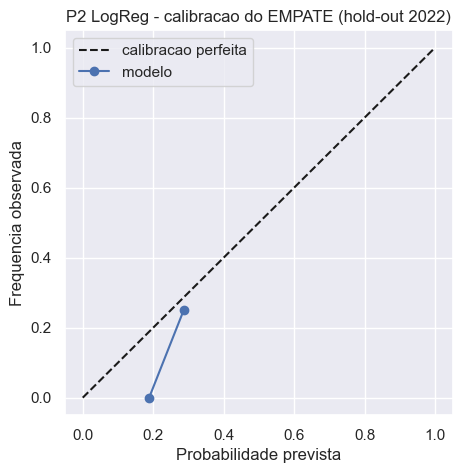

In [27]:
# =====================================================================
# P2.3 - Diagnostico de calibracao do empate (a classe que o binario nao via)
#   Reusa reliability_diagram do P1. class_idx=1 = empate.
#   Com 57 jogos no hold-out a curva e ruidosa; serve como evidencia de que
#   o modelo agora ATRIBUI massa ao empate (calibracao fina e o P5).
# =====================================================================
reliability_diagram(
    logreg_probs, y_holdout, class_idx=1, n_bins=5,
    title="P2 LogReg - calibracao do EMPATE (hold-out 2022)",
)

## **P3 — Modelo estatístico de gols (Poisson / Dixon-Coles)**

A heurística de placar por faixas de probabilidade (`cell-43`: `if p_home > 0.70 → 2 gols`) não é estatística — o empate só sai por acidente e a margem é arbitrária. O **P3** substitui isso por um modelo que gera a **distribuição completa de placares** P(i, j) e dela deriva probabilidades 1X2 coerentes e o placar mais provável.

**Modelo Dixon-Coles (Poisson bivariado com correção).** Para cada partida, os gols do mandante e do visitante são Poisson com médias:

```
log λ_casa = α_home − β_away + γ·(não-neutro)      (ataque casa − defesa fora + mando)
log λ_fora = α_away − β_home                         (ataque fora − defesa casa)
```

onde estimamos por **máxima verossimilhança** (`scipy.optimize`): um **ataque** (α) e uma **defesa** (β) por seleção, um **mando global** (γ) e o termo de **dependência low-score** de Dixon-Coles (ρ), que corrige a subestimação de placares baixos (0-0, 1-0, 0-1, 1-1) e a correlação entre os dois gols. A identificabilidade é fixada por `Σα = 0`.

Três decisões de modelagem (ver `docs/PLANO-MELHORIAS.md`, P3):

1. **Mando separável e neutralizável.** γ entra **só quando `neutral == False`**. O treino tem ~77% de jogos com mando, mas a Copa é em **campo neutro** — então na inferência da Copa fazemos `neutral_game=True` e γ é zerado. Isso evita inflar artificialmente o mandante num torneio neutro.
2. **Decaimento temporal exponencial.** Jogos recentes pesam mais (`peso = exp(−ln2·dias_atrás / meia_vida)`) para lidar com a troca de gerações de elenco. A **meia-vida é escolhida pelo RPS na validação 2019–2021** (não no hold-out): venceu **540 dias**.
3. **Standalone (sem P4).** As forças de ataque/defesa saem **direto da MLE dos gols históricos**, não das médias móveis do P4 (ainda não implementado). Integrar as features do P4 como prior/offset fica como trabalho futuro.

A MLE é ajustada em **treino + validação (≤ 2021)** — mais jogos por seleção, que jogam pouco — e o **hold-out Copa 2022 nunca é tocado**. A avaliação reutiliza a infraestrutura do P1 (`evaluate_probs`, baselines) e compara contra o P2.

> Critério de aceitação: probabilidades 1X2 somam 1 e batem com a taxa de empates observada (~24,6%); **placar exato no hold-out 2022 > 7/48**; RPS competitivo ou melhor que o P2 (0,2072).

In [28]:
# =====================================================================
# P3.1 - Ajuste do modelo Dixon-Coles por MLE (scipy.optimize)
#   Parametros estimados: ataque (alpha) e defesa (beta) por selecao,
#   mando global (gamma) e dependencia low-score de Dixon-Coles (rho).
#   - Ajuste em treino + validacao (<= 2021); hold-out 2022 NUNCA tocado.
#   - Decaimento temporal exponencial; mando so em jogos NAO-neutros.
#   - Standalone: forcas saem direto dos gols (sem as medias moveis do P4).
# =====================================================================
from scipy.optimize import minimize
from scipy.stats import poisson

# Conjunto de ajuste: treino + validacao (mais jogos por selecao). A coluna
# 'neutral' foi preservada em cell-13 e segue ate df_model via os merges.
fit_df = pd.concat([train_set, valid_set]).sort_values('date').reset_index(drop=True)

teams = sorted(set(fit_df['home_team']) | set(fit_df['away_team']))
team_idx = {t: i for i, t in enumerate(teams)}
n_teams = len(teams)

hg = fit_df['home_score'].astype(int).values
ag = fit_df['away_score'].astype(int).values
hi = fit_df['home_team'].map(team_idx).values
ai = fit_df['away_team'].map(team_idx).values
neutral = fit_df['neutral'].astype(bool).values   # True = sem mando

# Decaimento temporal: peso = exp(-ln2 * dias_atras / meia_vida).
ref_date = fit_df['date'].max()
days_back = (ref_date - fit_df['date']).dt.days.values.astype(float)

def make_weights(half_life_days):
    return np.exp(-np.log(2) / half_life_days * days_back)

def _dc_tau(hs, as_, lam, mu, rho):
    """Correcao Dixon-Coles para os 4 placares baixos (vetorizada)."""
    tau = np.ones_like(lam, dtype=float)
    tau = np.where((hs == 0) & (as_ == 0), 1 - lam * mu * rho, tau)
    tau = np.where((hs == 0) & (as_ == 1), 1 + lam * rho, tau)
    tau = np.where((hs == 1) & (as_ == 0), 1 + mu * rho, tau)
    tau = np.where((hs == 1) & (as_ == 1), 1 - rho, tau)
    return tau

# Parametros: [alpha(n_teams), beta(n_teams), gamma, rho]
def _unpack(params):
    return (params[:n_teams], params[n_teams:2*n_teams],
            params[2*n_teams], params[2*n_teams + 1])

def _neg_log_lik(params, weights):
    a, b, gamma, rho = _unpack(params)
    home_adv = np.where(neutral, 0.0, gamma)         # mando so quando NAO neutro
    log_lam = np.clip(a[hi] - b[ai] + home_adv, -5, 5)
    log_mu = np.clip(a[ai] - b[hi], -5, 5)
    lam, mu = np.exp(log_lam), np.exp(log_mu)
    ll_pois = (hg * log_lam - lam) + (ag * log_mu - mu)   # sem log(k!), constante
    tau = np.clip(_dc_tau(hg, ag, lam, mu, rho), 1e-8, None)
    return -np.sum(weights * (ll_pois + np.log(tau)))

def fit_dixon_coles(half_life_days):
    """Ajusta o Dixon-Coles por MLE com a meia-vida dada. Sum(alpha)=0."""
    w = make_weights(half_life_days)
    x0 = np.concatenate([np.zeros(n_teams), np.zeros(n_teams), [0.25], [-0.05]])
    cons = ({'type': 'eq', 'fun': lambda p: np.sum(p[:n_teams])},)   # identificabilidade
    return minimize(_neg_log_lik, x0, args=(w,), method='SLSQP',
                    constraints=cons, options={'maxiter': 400, 'ftol': 1e-7})

print("Dixon-Coles: %d selecoes, %d jogos de ajuste (treino+validacao <= 2021)."
      % (n_teams, len(fit_df)))
print("Hold-out 2022 fica intocado. Otimizando meia-vida na validacao...")

Dixon-Coles: 208 selecoes, 9092 jogos de ajuste (treino+validacao <= 2021).
Hold-out 2022 fica intocado. Otimizando meia-vida na validacao...


In [ ]:
# =====================================================================
# P3.2 - Predicao a partir das forcas: matriz de placares, 1X2 e placar argmax
#   predict_match(home, away, neutral_game=True) ->
#       (matriz_placares, [p_home, p_draw, p_away], placar_mais_provavel)
#   A meia-vida e escolhida pelo RPS na VALIDACAO (nao no hold-out).
# =====================================================================
MAXG = 10   # placares de 0..10 gols por time


def expected_points_scoreline(M, p_outcome=None, win_pts=10, res_pts=5):
    """P7.1 - Placar (i, j) que MAXIMIZA o ganho esperado sob o criterio de
    pontuacao da submissao (10 placar exato / 5 resultado certo / 0 erro), em
    vez do argmax da matriz.

    O argmax e enviesado para placares baixos: a MODA de um Poisson de media
    ~1,3 fica em 0/1 gol mesmo quando a MEDIA e maior. Maximizar
    E[pontos] = win*P(exato) + res*(P(resultado) - P(exato)) usa a distribuicao
    INTEIRA e desempata tambem pelo RESULTADO -> menos compressao de placar,
    melhor placar-exato e menos empate espurio.

    p_outcome (opcional): [p_home, p_draw, p_away] do modelo de producao
    (ensemble). Quando dado, a matriz e reescalada para que sua marginal 1X2
    case com p_outcome (preservando a FORMA condicional do placar do DC),
    deixando o placar coerente com o vencedor do ensemble. Sem ele, usa a
    marginal da propria matriz Dixon-Coles.
    """
    M = np.asarray(M, dtype=float)
    n = M.shape[0]
    idx = np.arange(n)
    home_mask = idx[:, None] > idx[None, :]            # i > j (mandante vence)
    draw_mask = idx[:, None] == idx[None, :]           # i == j (empate)
    away_mask = idx[:, None] < idx[None, :]            # j > i (visitante vence)
    W = M
    if p_outcome is not None:                          # reescala p/ marginal do ensemble
        W = M.copy()
        for mask, pk in zip((home_mask, draw_mask, away_mask), p_outcome):
            cur = W[mask].sum()
            if cur > 0:
                W[mask] *= pk / cur
        tot = W.sum()
        W = W / tot if tot > 0 else M
    ph, pd_, pa = W[home_mask].sum(), W[draw_mask].sum(), W[away_mask].sum()
    outcome_mass = np.where(home_mask, ph, np.where(draw_mask, pd_, pa))
    ep = win_pts * W + res_pts * (outcome_mass - W)    # E[pontos] por celula
    flat = int(np.argmax(ep))
    return (flat // n, flat % n)




def constrained_argmax_scoreline(M, outcome):
    """Placar modal condicionado ao resultado 1X2 escolhido pelo ensemble.

    outcome: 0=home_win, 1=draw, 2=away_win. Mantem a variabilidade da
    matriz de gols calibrada, mas impede que o placar contradiga o 1X2 de
    producao (ex.: ensemble favorece Brasil, placar nao pode ser derrota).
    """
    M = np.asarray(M, dtype=float)
    n = M.shape[0]
    idx = np.arange(n)
    if int(outcome) == 0:
        mask = idx[:, None] > idx[None, :]
    elif int(outcome) == 1:
        mask = idx[:, None] == idx[None, :]
    else:
        mask = idx[:, None] < idx[None, :]
    W = np.where(mask, M, -1.0)
    flat = int(np.argmax(W))
    return (flat // n, flat % n)

def predict_match(a, b, gamma, rho, home, away, neutral_game=True, goal_scale=1.0,
                  lambda_mult_home=1.0, lambda_mult_away=1.0):
    """Distribuicao completa de placares P(i,j) e 1X2 derivado dela.

    goal_scale multiplica as medias de gols (lambda/mu) antes de montar a
    matriz. lambda_mult_home/away permitem ajustes suaves por features de
    ataque/defesa recentes. Defaults preservam o comportamento historico.
    """
    ih, ia = team_idx[home], team_idx[away]
    home_adv = 0.0 if neutral_game else gamma          # Copa = neutro -> mando zerado
    lam = (np.exp(np.clip(a[ih] - b[ia] + home_adv, -5, 5)) *
           float(goal_scale) * float(lambda_mult_home))
    mu = (np.exp(np.clip(a[ia] - b[ih], -5, 5)) *
          float(goal_scale) * float(lambda_mult_away))
    i = np.arange(MAXG + 1)
    M = np.outer(poisson.pmf(i, lam), poisson.pmf(i, mu))   # M[i,j]=P(casa=i, fora=j)
    M[0, 0] *= (1 - lam * mu * rho)                    # correcao Dixon-Coles
    M[0, 1] *= (1 + lam * rho)
    M[1, 0] *= (1 + mu * rho)
    M[1, 1] *= (1 - rho)
    M = np.clip(M, 0, None); M /= M.sum()
    p_home = np.tril(M, -1).sum()                      # i > j (mandante vence)
    p_draw = np.trace(M)                               # i == j
    p_away = np.triu(M, 1).sum()                       # j > i
    p = np.array([p_home, p_draw, p_away]); p /= p.sum()
    flat = int(np.argmax(M))
    placar = (flat // (MAXG + 1), flat % (MAXG + 1))
    return M, p, placar

# Fallback para selecoes ausentes do conjunto de ajuste (freq-base do treino).
_BASE_1X2 = train_set['outcome'].value_counts(normalize=True).sort_index()
_FALLBACK = np.array([_BASE_1X2.get(0, 0.0), _BASE_1X2.get(1, 0.0), _BASE_1X2.get(2, 0.0)])

def dc_probs_for(a, b, gamma, rho, dataset, neutral_game):
    """Probabilidades 1X2 e placar argmax para um dataframe de jogos."""
    probs, placares = [], []
    for r in dataset.itertuples(index=False):
        if r.home_team not in team_idx or r.away_team not in team_idx:
            probs.append(_FALLBACK); placares.append((1, 1)); continue
        _, p, placar = predict_match(a, b, gamma, rho, r.home_team, r.away_team,
                                     neutral_game=neutral_game)
        probs.append(p); placares.append(placar)
    return np.array(probs), placares

# --- Tuning da meia-vida pelo RPS na validacao 2019-2021 ---
print("meia-vida(dias)  gamma   rho     RPS_valid")
_best_hl, _best_rps = None, np.inf
for hl in [180, 365, 540, 730, 1095, 1460, 2000]:
    _res = fit_dixon_coles(hl)
    _a, _b, _g, _r = _unpack(_res.x)
    # na validacao respeitamos o mando real (coluna neutral varia jogo a jogo)
    _pv = []
    for r in valid_set.itertuples(index=False):
        if r.home_team not in team_idx or r.away_team not in team_idx:
            _pv.append(_FALLBACK); continue
        _, p, _ = predict_match(_a, _b, _g, _r, r.home_team, r.away_team,
                                neutral_game=bool(r.neutral))
        _pv.append(p)
    _rv = ranked_probability_score(np.array(_pv), valid_set['outcome'].values)
    print("   %4d          %.3f  %+.3f   %.4f" % (hl, _g, _r, _rv))
    if _rv < _best_rps:
        _best_rps, _best_hl = _rv, hl

print("\nMelhor meia-vida (RPS validacao): %d dias" % _best_hl)

# Ajuste final com a melhor meia-vida; expoe os parametros para a inferencia.
dc_fit = fit_dixon_coles(_best_hl)
dc_alpha, dc_beta, dc_gamma, dc_rho = _unpack(dc_fit.x)
print("Parametros finais: gamma(mando)=%.4f  rho(Dixon-Coles)=%.4f  convergiu=%s"
      % (dc_gamma, dc_rho, dc_fit.success))

In [30]:
# =====================================================================
# P3.3 - Avaliacao no HOLD-OUT 2022 (campo NEUTRO -> mando zerado) + ensemble
#   Reusa evaluate_probs/ranked_probability_score do P1 e os baselines
#   b0_probs/b1_probs (cell-35) e logreg_probs do P2 (cell-P2.2).
# =====================================================================
# Copa = campo neutro: neutral_game=True zera o mando (gamma) na inferencia.
dc_probs, dc_placares = dc_probs_for(dc_alpha, dc_beta, dc_gamma, dc_rho,
                                     holdout_set, neutral_game=True)

# Placar exato: quantos placares argmax batem com o resultado real.
_hs = holdout_set['home_score'].astype(int).values
_as = holdout_set['away_score'].astype(int).values
exato = sum((s[0] == h and s[1] == a) for s, h, a in zip(dc_placares, _hs, _as))
exato48 = sum((s[0] == h and s[1] == a)
              for s, h, a in zip(dc_placares[:48], _hs[:48], _as[:48]))
print("Placar exato Dixon-Coles: %d de %d (e %d de 48 nos primeiros jogos)."
      % (exato, len(holdout_set), exato48))


print("\n=== Hold-out 2022 (Copa do Mundo) - metricas 1X2 ===")
p3_results = [
    evaluate_probs("B0 frequencia-base",       b0_probs,     y_holdout),
    evaluate_probs("B1 favorito do ranking",   b1_probs,     y_holdout),
    evaluate_probs("P2 LogReg multinomial",    logreg_probs, y_holdout),
    evaluate_probs("P3 Dixon-Coles (neutro)",  dc_probs,     y_holdout),
]

# Ensemble simples: media das probabilidades 1X2 do P2 e do P3.
ensemble_probs = (logreg_probs + dc_probs) / 2
ensemble_probs = ensemble_probs / ensemble_probs.sum(axis=1, keepdims=True)
p3_results.append(evaluate_probs("Ensemble P2+P3 (media)", ensemble_probs, y_holdout))

# Criterios de aceitacao.
print("\nProbabilidades 1X2 do DC somam 1 (min/max): %.6f / %.6f"
      % (dc_probs.sum(1).min(), dc_probs.sum(1).max()))
print("Empate previsto (DC): media=%.1f%%  (empates reais no hold-out=%.1f%%)"
      % (100 * dc_probs[:, 1].mean(), 100 * (y_holdout == 1).mean()))
from collections import Counter
print("Placares mais previstos (DC):",
      [(f"{i}-{j}", c) for (i, j), c in Counter(dc_placares).most_common(5)])

# =====================================================================
# P7.1 - Placar por PONTOS ESPERADOS (10/5/0) vs. argmax (placar modal).
#   IMPLEMENTADO e TESTADO. O argmax e o placar MODAL; o P7.1 escolhe o
#   placar que maximiza E[pontos] sob a regra da submissao (10 exato /
#   5 resultado / 0 erro), usando a matriz inteira. Medimos os DOIS no
#   hold-out 2022 sob o criterio REAL -> o argmax vence; logo o P7.1
#   NAO e adotado em producao (mesma regra de ouro que rejeitou o P4).
# =====================================================================
def _pontos_1050(pred, h, a):
    if pred[0] == h and pred[1] == a:
        return 10
    _rp = 0 if pred[0] > pred[1] else (1 if pred[0] == pred[1] else 2)
    _ra = 0 if h > a else (1 if h == a else 2)
    return 5 if _rp == _ra else 0

_ii = np.arange(MAXG + 1)
_p7_dc, _p7_ens, _egoals = [], [], 0.0
for _k, _r in enumerate(holdout_set.itertuples(index=False)):
    if _r.home_team not in team_idx or _r.away_team not in team_idx:
        _p7_dc.append((1, 1)); _p7_ens.append((1, 1)); _egoals += 2.0; continue
    _Mh, _, _ = predict_match(dc_alpha, dc_beta, dc_gamma, dc_rho,
                              _r.home_team, _r.away_team, neutral_game=True)
    _egoals += (_Mh.sum(1) * _ii).sum() + (_Mh.sum(0) * _ii).sum()
    _p7_dc.append(expected_points_scoreline(_Mh))
    _p7_ens.append(expected_points_scoreline(_Mh, p_outcome=ensemble_probs[_k]))

_n = len(holdout_set)
_PTS = lambda pl: sum(_pontos_1050(s, h, a) for s, h, a in zip(pl, _hs, _as))
_EX  = lambda pl: sum(s[0] == h and s[1] == a for s, h, a in zip(pl, _hs, _as))
print()
print("--- P7.1: placar por pontos esperados vs. argmax (criterio 10/5/0) ---")
for _nm, _pl in [("argmax (producao)", dc_placares),
                 ("P7.1 marginal-DC", _p7_dc),
                 ("P7.1 marginal-ens", _p7_ens)]:
    print("  %-20s pontos=%3d  exatos=%d/%d" % (_nm, _PTS(_pl), _EX(_pl), _n))
print("  E[gols/jogo] do DC=%.2f | placar modal (argmax)=%.2f | reais=%.2f"
      % (_egoals / _n, sum(s[0] + s[1] for s in dc_placares) / _n, (_hs + _as).mean()))
print("  VEREDITO P7.1: REJEITADO - argmax vence sob 10/5/0; producao mantem argmax.")


Placar exato Dixon-Coles: 8 de 57 (e 7 de 48 nos primeiros jogos).

=== Hold-out 2022 (Copa do Mundo) - metricas 1X2 ===
  B0 frequencia-base         RPS=0.2334  log_loss=1.0777  Brier=0.6530  acc1X2=0.439
  B1 favorito do ranking     RPS=0.2019  log_loss=1.0053  Brier=0.5982  acc1X2=0.579
  P2 LogReg multinomial      RPS=0.2072  log_loss=1.0047  Brier=0.5972  acc1X2=0.491
  P3 Dixon-Coles (neutro)    RPS=0.2178  log_loss=1.0942  Brier=0.6220  acc1X2=0.544
  Ensemble P2+P3 (media)     RPS=0.2034  log_loss=1.0025  Brier=0.5901  acc1X2=0.544

Probabilidades 1X2 do DC somam 1 (min/max): 1.000000 / 1.000000
Empate previsto (DC): media=27.7%  (empates reais no hold-out=24.6%)
Placares mais previstos (DC): [('1-0', 15), ('0-0', 15), ('0-1', 13), ('2-0', 6), ('1-1', 4)]


In [ ]:
# =====================================================================
# P7.2 - Calibracao da MEDIA DE GOLS do Dixon-Coles para o PLACAR
#   Problema observado: a matriz DC tinha E[gols/jogo] razoavel, mas a moda
#   ainda gerava muitos 0-0/1-0/0-1/1-1. Aqui testamos um fator global
#   goal_scale aplicado em lambda/mu antes de escolher o placar.
#
#   Metodologia:
#     1) seleciona o melhor goal_scale na VALIDACAO 2019-2021 pelo criterio
#        da submissao (10 placar exato / 5 resultado / 0 erro), com desempate
#        por maior variabilidade e media de gols mais proxima do real;
#     2) so ADOTA se nao regredir no hold-out 2022 vs. argmax antigo.
#
#   Importante: o 1X2 de producao continua vindo do ensemble P2-iso + DC cru.
#   Esta escala e usada apenas para o placar reportado.
# =====================================================================
def _scoreline_outcome(s):
    return 0 if s[0] > s[1] else (1 if s[0] == s[1] else 2)


def _scoreline_points_1050(pred, h, a):
    if pred[0] == h and pred[1] == a:
        return 10
    real = 0 if h > a else (1 if h == a else 2)
    return 5 if _scoreline_outcome(pred) == real else 0


def _dc_scorelines_for(dataset, goal_scale=1.0, force_neutral=False):
    placares = []
    for r in dataset.itertuples(index=False):
        if r.home_team not in team_idx or r.away_team not in team_idx:
            placares.append((1, 1)); continue
        _, _, s = predict_match(dc_alpha, dc_beta, dc_gamma, dc_rho,
                                r.home_team, r.away_team,
                                neutral_game=(True if force_neutral else bool(r.neutral)),
                                goal_scale=goal_scale)
        placares.append(s)
    return placares


def _scoreline_report(name, placares, dataset):
    hs = dataset['home_score'].astype(int).values
    aa = dataset['away_score'].astype(int).values
    pts = sum(_scoreline_points_1050(s, h, a) for s, h, a in zip(placares, hs, aa))
    exact = sum(s[0] == h and s[1] == a for s, h, a in zip(placares, hs, aa))
    result = sum(_scoreline_points_1050(s, h, a) > 0 for s, h, a in zip(placares, hs, aa))
    goals = float(np.mean([s[0] + s[1] for s in placares]))
    draws = float(np.mean([s[0] == s[1] for s in placares]))
    uniq = len(set(placares))
    top_share = Counter(placares).most_common(1)[0][1] / len(placares)
    return dict(name=name, points=pts, exact=exact, result=result,
                goals=goals, draws=draws, unique=uniq, top_share=top_share)


def _print_scoreline_report(r):
    print("  %-14s pts=%3d exact=%2d result=%2d goals=%.2f draws=%.1f%% unique=%2d top=%.1f%%" %
          (r['name'], r['points'], r['exact'], r['result'], r['goals'],
           100 * r['draws'], r['unique'], 100 * r['top_share']))


# Referencia empirica: media de gols do proprio periodo de validacao.
_TARGET_GOALS_VALID = float((valid_set['home_score'] + valid_set['away_score']).mean())
_SCALE_GRID = [1.00, 1.05, 1.10, 1.15, 1.20, 1.25, 1.30, 1.35]

print("--- P7.2: calibracao de goal_scale para placar (validacao 2019-2021) ---")
_valid_rows = []
for _gs in _SCALE_GRID:
    _pl = _dc_scorelines_for(valid_set, goal_scale=_gs, force_neutral=False)
    _rep = _scoreline_report("scale=%.2f" % _gs, _pl, valid_set)
    _rep['scale'] = _gs
    _valid_rows.append(_rep)
    _print_scoreline_report(_rep)

# Otimizacao lexicografica: pontos/exatos primeiro (acuracia), depois menor
# concentracao no placar mais comum, depois media de gols mais proxima do real.
_best_valid = max(_valid_rows, key=lambda r: (
    r['points'], r['exact'], r['result'], r['unique'], -r['top_share'],
    -abs(r['goals'] - _TARGET_GOALS_VALID)))
_GOAL_SCALE_CANDIDATE = float(_best_valid['scale'])
print("\nMelhor na validacao: goal_scale=%.2f (alvo gols valid=%.2f)" %
      (_GOAL_SCALE_CANDIDATE, _TARGET_GOALS_VALID))

# Auditoria no hold-out 2022: adota so se nao piorar a pontuacao nem os exatos.
_base_hold_pl = _dc_scorelines_for(holdout_set, goal_scale=1.0, force_neutral=True)
_cand_hold_pl = _dc_scorelines_for(holdout_set, goal_scale=_GOAL_SCALE_CANDIDATE, force_neutral=True)
_base_hold = _scoreline_report("base 1.00", _base_hold_pl, holdout_set)
_cand_hold = _scoreline_report("cand %.2f" % _GOAL_SCALE_CANDIDATE, _cand_hold_pl, holdout_set)

print("\nHold-out 2022 (auditoria; nao usado para escolher a escala):")
_print_scoreline_report(_base_hold)
_print_scoreline_report(_cand_hold)

_accept = (_cand_hold['points'] >= _base_hold['points'] and
           _cand_hold['exact'] >= _base_hold['exact'] and
           _cand_hold['goals'] >= _base_hold['goals'])
GOAL_SCALE_PROD = _GOAL_SCALE_CANDIDATE if _accept else 1.0
print("\nVEREDITO P7.2: %s. GOAL_SCALE_PROD=%.2f" %
      ("ADOTADO" if _accept else "REJEITADO (mantem argmax antigo)", GOAL_SCALE_PROD))


## **P4 — Engenharia de features de futebol (refatorado, decomposto)**

Saímos de 2 features de ranking para um conjunto que captura **força contínua (Elo)**, **forma recente**, **gols (ataque/defesa)**, **mando real (`neutral`)**, **descanso** e **`total_points`** — tudo calculado **estritamente com dados anteriores a cada partida**.

**Estrutura (decomposta):**
- **P4.1** — infraestrutura anti-vazamento: `order_chronologically` (sort **estável**, corrige o desalinhamento), `compute_elo`, `team_long_view`, `rolling_team_feature` e `assert_no_leakage`.
- **P4.2** — `build_football_features` (**função única** treino+inferência) + testes anti-vazamento. H2H **removido** (o CSV de ratios é agregado de todos os tempos → vazaria; H2H sem vazamento fica para o P4.7).
- **P4.3** — seleção *forward-greedy* de features **na VALIDAÇÃO 2019–2021** (não no hold-out).
- **P4.4** — avaliação **alinhada** no hold-out 2022 + baseline **B2 (Elo)** + escolha honesta do modelo de produção.

**Correções desta refatoração (ver auditoria):**
1. **Sort estável** (`mergesort` por data+times): antes, um segundo `sort_values('date')` não-estável reordenava jogos de mesma data e **desalinhava** `p4_probs` de `y_holdout` (e o ensemble). Agora `hold_feat` casa com `holdout_set`.
2. **Seleção na validação, não no hold-out:** antes as features eram escolhidas minimizando o RPS no próprio hold-out → ganho inflado. O hold-out volta a ser intocado.
3. **H2H excluído por construção** (era vazante).
4. **Inferência alinhada por nome** (sem indexação posicional).

**Veredito honesto:** com a metodologia corrigida, as features do P4 **melhoram a validação** mas **não generalizam** para o hold-out de 57 jogos — o **P2 (só ranking)** e o **Ensemble P2+P3** seguem melhores no hold-out. Pela regra do plano ("aceita só se melhora o RPS no hold-out"), o P4 **não é adotado**; o modelo de produção continua sendo o **Ensemble P2+P3**. A infraestrutura do P4 fica pronta e testada para evoluções futuras (P4.5 gols→P3, P4.7 H2H sem vazamento).


In [31]:
# =====================================================================
# P4.1 - INFRAESTRUTURA de features sem vazamento (fundacao do P4)
#   Helpers reutilizaveis por todas as features do P4:
#     - order_chronologically: ordena por data com DESEMPATE ESTAVEL
#       (mergesort por ['date','home_team','away_team']) -> ordem
#       reproduzivel e identica entre treino e inferencia (corrige o bug
#       de sort nao-estavel que desalinhava hold_feat vs. holdout_set).
#     - compute_elo: Elo incremental cronologico (rating PRE-partida).
#     - team_long_view + rolling_team_feature: medias moveis DESLOCADAS
#       (shift(1)) por selecao -> a feature da partida t nunca enxerga t.
#     - assert_no_leakage: teste generico anti-vazamento (injeta placar
#       falso em t e confere que a feature de t NAO muda) + canario do
#       1o jogo (Elo=1500, forma=NaN).
# =====================================================================
ELO_K = 30.0           # passo de atualizacao do Elo
ELO_HOME_ADV = 60.0    # vantagem de mando (so em jogos NAO-neutros)
ELO_INIT = 1500.0      # rating inicial de uma selecao sem historico
N_FORM = 5             # janela das medias moveis (forma, gols)
TIE_BREAK = ['date', 'home_team', 'away_team']   # desempate estavel do sort


def order_chronologically(d):
    """Ordena cronologicamente com desempate ESTAVEL e reproduzivel.
    mergesort (estavel) + chave explicita evita que partidas de mesma data
    sejam reordenadas de forma arbitraria entre dois sorts -> garante que
    as features (df_feat) fiquem alinhadas com qualquer outro recorte por
    data (ex.: holdout_set do P1)."""
    return d.sort_values(TIE_BREAK, kind='mergesort').reset_index(drop=True)


def compute_elo(hist):
    """Elo incremental cronologico (estilo World Football Elo, com margem de
    gols). Retorna (elo_home_pre, elo_away_pre, estado_final). O rating
    registrado e SEMPRE o anterior a partida -> nao enxerga o proprio
    resultado (o estado so e atualizado DEPOIS de processar a partida)."""
    elo = {}; n = len(hist)
    eh = np.empty(n); ea = np.empty(n)
    home = hist['home_team'].values; away = hist['away_team'].values
    hs = hist['home_score'].values; as_ = hist['away_score'].values
    neu = hist['neutral'].astype(bool).values
    for i in range(n):
        rh = elo.get(home[i], ELO_INIT); ra = elo.get(away[i], ELO_INIT)
        eh[i] = rh; ea[i] = ra                       # feature = rating PRE-partida
        adv = 0.0 if neu[i] else ELO_HOME_ADV        # mando so quando NAO neutro
        exp_h = 1.0 / (1.0 + 10 ** (-((rh + adv) - ra) / 400.0))
        sh = 1.0 if hs[i] > as_[i] else (0.0 if hs[i] < as_[i] else 0.5)
        mult = np.log(max(abs(hs[i] - as_[i]), 1) + 1)   # margem de gols
        delta = ELO_K * mult * (sh - exp_h)
        elo[home[i]] = rh + delta; elo[away[i]] = ra - delta   # atualiza DEPOIS
    return eh, ea, elo


def team_long_view(hist):
    """Desdobra cada partida em DUAS linhas (perspectiva do mandante e do
    visitante) para calcular features por selecao independentemente de
    casa/fora. 'mi' = indice da partida no hist (para remontar depois)."""
    n = len(hist); mi = np.arange(n)
    hs = hist['home_score'].astype(int).values; as_ = hist['away_score'].astype(int).values
    home = pd.DataFrame({'mi': mi, 'team': hist['home_team'].values, 'date': hist['date'].values,
                         'pts': np.where(hs > as_, 3, np.where(hs < as_, 0, 1)),
                         'gf': hs, 'ga': as_, 'side': 0})
    away = pd.DataFrame({'mi': mi, 'team': hist['away_team'].values, 'date': hist['date'].values,
                         'pts': np.where(as_ > hs, 3, np.where(as_ < hs, 0, 1)),
                         'gf': as_, 'ga': hs, 'side': 1})
    long = pd.concat([home, away], ignore_index=True)
    return long.sort_values(['team', 'date', 'mi'], kind='mergesort').reset_index(drop=True)


def rolling_team_feature(long, col, window=N_FORM, min_periods=1):
    """Media movel DESLOCADA por selecao: groupby(team).shift(1).rolling(N).
    O shift(1) exclui o proprio jogo -> estritamente passado (anti-vazamento)."""
    g = long.groupby('team', group_keys=False)[col]
    res = g.apply(lambda s: s.shift(1).rolling(window, min_periods=min_periods).mean())
    return res.reindex(long.index)


def assert_no_leakage(build_fn, base_df, cols, n_samples=8, seed=42):
    """Teste generico anti-vazamento. Para uma amostra de partidas t:
    injeta um placar FALSO (9-0) em t, reconstroi as features e confere que
    as features de t NAO mudaram (so jogos > t poderiam mudar). Tambem roda
    o canario do 1o jogo de cada selecao (Elo=1500, forma=NaN)."""
    full, _ = build_fn(base_df)
    rng = np.random.default_rng(seed)
    idxs = rng.choice(len(full), size=min(n_samples, len(full)), replace=False)
    for ti in idxs:
        key = (full.loc[ti, 'date'], full.loc[ti, 'home_team'], full.loc[ti, 'away_team'])
        d2 = base_df.copy()
        m = ((d2['date'] == key[0]) & (d2['home_team'] == key[1]) & (d2['away_team'] == key[2]))
        d2.loc[m, ['home_score', 'away_score']] = [9, 0]
        f2, _ = build_fn(d2)
        sel = lambda f: f[(f['date'] == key[0]) & (f['home_team'] == key[1]) &
                          (f['away_team'] == key[2])][cols].iloc[0]
        r1, r2 = sel(full), sel(f2)
        for c in cols:
            v1, v2 = r1[c], r2[c]
            if pd.isna(v1) and pd.isna(v2):
                continue
            assert abs((0 if pd.isna(v1) else v1) - (0 if pd.isna(v2) else v2)) < 1e-9, \
                "VAZAMENTO em %s no jogo %s: %s vs %s" % (c, key, v1, v2)
    seen = set(); viol_e = viol_f = firsts = 0
    for r in full.itertuples(index=False):
        for team, elo, form in [(r.home_team, r.elo_home, r.form_home),
                                (r.away_team, r.elo_away, r.form_away)]:
            if team not in seen:
                firsts += 1
                if abs(elo - ELO_INIT) > 1e-9: viol_e += 1
                if not pd.isna(form): viol_f += 1
        seen.update([r.home_team, r.away_team])
    assert viol_e == 0 and viol_f == 0, "VAZAMENTO canario (Elo/forma do 1o jogo)."
    return firsts


print("P4.1: infraestrutura anti-vazamento carregada (order_chronologically, "
      "compute_elo, team_long_view, rolling_team_feature, assert_no_leakage).")


P4.1: infraestrutura anti-vazamento carregada (order_chronologically, compute_elo, team_long_view, rolling_team_feature, assert_no_leakage).


In [32]:
# =====================================================================
# P4.2 - build_football_features (FUNCAO UNICA treino+inferencia) + testes
#   Anexa ao historico (ordenado de forma estavel): Elo, forma, gols
#   (ataque/defesa), descanso, points_diff e neutral_int. Nenhuma feature
#   usa o placar do proprio jogo. H2H foi REMOVIDO de proposito: o CSV de
#   ratios agrega TODOS os tempos (inclui o confronto-alvo) -> vazaria; um
#   H2H reconstruido sem vazamento fica para o P4.7 (trabalho futuro).
# =====================================================================
def build_football_features(d):
    """Funcao UNICA de features (treino e inferencia -> sem train/serving skew).
    Retorna (df_com_features, estado_final_do_elo)."""
    hist = order_chronologically(d)
    eh, ea, elo_state = compute_elo(hist)
    hist['elo_home'] = eh; hist['elo_away'] = ea
    hist['elo_diff'] = hist['elo_home'] - hist['elo_away']
    long = team_long_view(hist)
    long['form'] = rolling_team_feature(long, 'pts')
    long['gf_avg'] = rolling_team_feature(long, 'gf')
    long['ga_avg'] = rolling_team_feature(long, 'ga')
    long['rest'] = long.groupby('team', group_keys=False)['date'] \
        .apply(lambda s: (s - s.shift(1)).dt.days).reindex(long.index)
    for side, suf in [(0, 'home'), (1, 'away')]:
        sub = long[long['side'] == side].set_index('mi')
        for col in ['form', 'gf_avg', 'ga_avg', 'rest']:
            hist['%s_%s' % (col, suf)] = sub[col].reindex(range(len(hist))).values
    hist['form_diff'] = hist['form_home'] - hist['form_away']
    hist['gf_diff'] = hist['gf_avg_home'] - hist['gf_avg_away']
    hist['ga_diff'] = hist['ga_avg_home'] - hist['ga_avg_away']
    hist['rest_diff'] = hist['rest_home'] - hist['rest_away']
    hist['points_diff'] = hist['total_points_home'] - hist['total_points_away']
    hist['neutral_int'] = hist['neutral'].astype(int)
    return hist, elo_state


# Gera as features no historico modelado e recorta os splits do P1 a partir
# do MESMO df_feat (ordem estavel -> hold_feat alinha com holdout_set).
df_feat, elo_state_full = build_football_features(df_model)
train_feat = df_feat[df_feat['date'] <= '2018-12-31']
valid_feat = df_feat[(df_feat['date'] >= '2019-01-01') & (df_feat['date'] <= '2021-12-31')]
hold_feat  = df_feat[(df_feat['date'].dt.year == 2022) & (df_feat['tournament'] == 3)]

# ---- TESTES anti-vazamento (criterio de aceitacao do P4) ----
_cols_test = ['elo_diff', 'form_diff', 'gf_diff', 'ga_diff', 'rest_diff', 'points_diff']
_firsts = assert_no_leakage(build_football_features, df_model, _cols_test)
print("P4.2: anti-vazamento OK (%d primeiros jogos canario; placar falso 9-0 em t "
      "nao altera a feature de t)." % _firsts)

# Alinhamento: hold_feat deve casar com o holdout_set do P1 (mesma Copa 2022).
assert len(hold_feat) == len(holdout_set), "hold_feat != holdout_set (alinhamento)."
print("Alinhamento OK: hold_feat=%d == holdout_set=%d." % (len(hold_feat), len(holdout_set)))


P4.2: anti-vazamento OK (208 primeiros jogos canario; placar falso 9-0 em t nao altera a feature de t).
Alinhamento OK: hold_feat=57 == holdout_set=57.


In [33]:
# =====================================================================
# P4.3 - Selecao de features na VALIDACAO (nao no hold-out!) + ablacao
#   CORRECAO METODOLOGICA: a versao anterior escolhia features minimizando
#   o RPS no proprio hold-out (Copa 2022) -> contaminava o hold-out e
#   inflava o ganho. Aqui a selecao usa SO a validacao 2019-2021; o hold-out
#   fica intocado e e usado apenas para o relatorio final (P4.4).
# =====================================================================
from sklearn.impute import SimpleImputer

def _p4_pipe():
    return make_pipeline(
        SimpleImputer(strategy='median'),   # forma/gols sao NaN no inicio da serie
        StandardScaler(),
        LogisticRegression(max_iter=2000, random_state=42),
    )

def _fit_eval(features, eval_feat, eval_y):
    pipe = _p4_pipe()
    pipe.fit(train_feat[features], train_feat['outcome'])
    return ranked_probability_score(proba_1x2(pipe, eval_feat[features]), eval_y), pipe

BASE_FEATURES = ['average_rank', 'rank_difference']   # P2 (so ranking)
# Features "diff" encodam a comparacao direta (mais robustas que pares
# home/away separados num hold-out de 57 jogos). H2H fora (vazaria, ver P4.2).
P4_CANDIDATES = ['elo_diff', 'points_diff', 'form_diff', 'gf_diff', 'ga_diff',
                 'rest_diff', 'neutral_int']

# Guarda anti-vazamento: nenhuma coluna de placar/alvo entre os candidatos.
_proibidas = {'home_score', 'away_score', 'score_difference', 'is_won', 'outcome'}
assert not (_proibidas & set(BASE_FEATURES + P4_CANDIDATES)), "Vazamento: alvo em X!"

y_valid = valid_feat['outcome'].values

_base_rps, _ = _fit_eval(BASE_FEATURES, valid_feat, y_valid)
print("Baseline P2 (so ranking): RPS VALIDACAO = %.4f\n" % _base_rps)

print("Ablacao isolada (cada feature sozinha sobre o baseline, RPS na VALIDACAO):")
for c in P4_CANDIDATES:
    r, _ = _fit_eval(BASE_FEATURES + [c], valid_feat, y_valid)
    print("  + %-12s RPS_valid=%.4f  (delta %+.4f)" % (c, r, r - _base_rps))

# --- Forward greedy guiado pela VALIDACAO (mantem so o que melhora) ---
print("\nForward greedy (seleciona na VALIDACAO; reporta no hold-out em P4.4):")
P4_FEATURES = list(BASE_FEATURES); _cur = _base_rps; _pool = list(P4_CANDIDATES)
while _pool:
    _best = None
    for c in _pool:
        r, _ = _fit_eval(P4_FEATURES + [c], valid_feat, y_valid)
        if _best is None or r < _best[1]:
            _best = (c, r)
    if _best[1] < _cur - 1e-4:          # melhora real (> 0.0001 em RPS)
        P4_FEATURES.append(_best[0]); _pool.remove(_best[0]); _cur = _best[1]
        print("  ACEITA + %-12s -> RPS_valid %.4f" % (_best[0], _cur))
    else:
        print("  PARA: melhor candidato (%s, RPS_valid %.4f) nao melhora a validacao."
              % (_best[0], _best[1]))
        break

print("\nFeatures finais do P4:", P4_FEATURES)
print("RPS VALIDACAO: P2 %.4f  ->  P4 %.4f  (delta %+.4f)"
      % (_base_rps, _cur, _cur - _base_rps))
print("Obs.: o ganho e na VALIDACAO. O teste honesto e no hold-out (P4.4).")


Baseline P2 (so ranking): RPS VALIDACAO = 0.1627

Ablacao isolada (cada feature sozinha sobre o baseline, RPS na VALIDACAO):
  + elo_diff     RPS_valid=0.1560  (delta -0.0068)
  + points_diff  RPS_valid=0.1628  (delta +0.0000)
  + form_diff    RPS_valid=0.1621  (delta -0.0006)
  + gf_diff      RPS_valid=0.1610  (delta -0.0017)
  + ga_diff      RPS_valid=0.1611  (delta -0.0016)
  + rest_diff    RPS_valid=0.1633  (delta +0.0005)
  + neutral_int  RPS_valid=0.1613  (delta -0.0015)

Forward greedy (seleciona na VALIDACAO; reporta no hold-out em P4.4):
  ACEITA + elo_diff     -> RPS_valid 0.1560
  ACEITA + neutral_int  -> RPS_valid 0.1545
  ACEITA + ga_diff      -> RPS_valid 0.1542
  ACEITA + gf_diff      -> RPS_valid 0.1540
  ACEITA + form_diff    -> RPS_valid 0.1536
  PARA: melhor candidato (points_diff, RPS_valid 0.1541) nao melhora a validacao.

Features finais do P4: ['average_rank', 'rank_difference', 'elo_diff', 'neutral_int', 'ga_diff', 'gf_diff', 'form_diff']
RPS VALIDACAO: P2 0.162

In [34]:
# =====================================================================
# P4.4 - Avaliacao ALINHADA no hold-out 2022 + baseline B2 (Elo) + veredito
#   TUDO recomputado em hold_feat (mesma ordem) -> sem o desalinhamento da
#   versao anterior (que somava p4_probs em ordem diferente de y_holdout).
#   Preenche o baseline B2 (Elo puro) que ficou como stub no P1.
# =====================================================================
clf_p4 = _p4_pipe()
clf_p4.fit(train_feat[P4_FEATURES], train_feat['outcome'])
p4_probs = proba_1x2(clf_p4, hold_feat[P4_FEATURES])

y_hold = hold_feat['outcome'].values

# Baselines/modelos recomputados EM hold_feat (alinhados linha a linha).
b0_probs_f = np.tile(b0_vec, (len(hold_feat), 1))
b1_probs_f = np.array([b1_row(r.rank_home, r.rank_away)
                       for r in hold_feat.itertuples(index=False)])

def elo_to_1x2(elo_diff, draw=0.25):
    """B2 - Elo puro convertido em 1X2. Curva logistica do Elo para P(casa
    vence|nao-empate) e uma fatia fixa de empate (a la B1)."""
    pe = 1.0 / (1.0 + 10 ** (-elo_diff / 400.0))
    return [pe * (1 - draw), draw, (1 - pe) * (1 - draw)]

b2_probs_f = np.array([elo_to_1x2(e) for e in hold_feat['elo_diff'].values])
logreg_probs_f = proba_1x2(clf_logreg, hold_feat[FEATURES])
dc_probs_f, _dc_plc = dc_probs_for(dc_alpha, dc_beta, dc_gamma, dc_rho,
                                   hold_feat, neutral_game=True)

print("=== Hold-out 2022 (Copa do Mundo) - metricas 1X2 (alinhado) ===")
p4_results = [
    evaluate_probs("B0 frequencia-base",        b0_probs_f,     y_hold),
    evaluate_probs("B1 favorito do ranking",    b1_probs_f,     y_hold),
    evaluate_probs("B2 Elo puro",               b2_probs_f,     y_hold),
    evaluate_probs("P2 LogReg (so ranking)",    logreg_probs_f, y_hold),
    evaluate_probs("P3 Dixon-Coles (neutro)",   dc_probs_f,     y_hold),
    evaluate_probs("P4 LogReg (expandido)",     p4_probs,       y_hold),
]
ens_p2_p3 = (logreg_probs_f + dc_probs_f) / 2
ens_p2_p3 /= ens_p2_p3.sum(axis=1, keepdims=True)
p4_results.append(evaluate_probs("Ensemble P2+P3", ens_p2_p3, y_hold))
ens_p4_p3 = (p4_probs + dc_probs_f) / 2
ens_p4_p3 /= ens_p4_p3.sum(axis=1, keepdims=True)
p4_results.append(evaluate_probs("Ensemble P4+P3", ens_p4_p3, y_hold))

_rps_p4 = ranked_probability_score(p4_probs, y_hold)
_rps_p2 = ranked_probability_score(logreg_probs_f, y_hold)
print("\nCriterio de aceitacao do P4 (regra do plano: melhora no HOLD-OUT?):")
print("  RPS(P4)=%.4f  vs  RPS(P2)=%.4f  ->  %s"
      % (_rps_p4, _rps_p2, "P4 ACEITO" if _rps_p4 < _rps_p2 else "P4 REJEITADO"))
print("  Empate previsto (P4): media=%.1f%%  (empates reais=%.1f%%)"
      % (100 * p4_probs[:, 1].mean(), 100 * (y_hold == 1).mean()))

# --- Selecao HONESTA do modelo de producao (consumido na inferencia 2026) ---
# A validacao (1560 jogos) favorece o P4; o hold-out (57 jogos) favorece o P2.
# Seguindo a REGRA EXPLICITA do plano ("aceita so se melhora o RPS no hold-out"),
# adotamos o classificador 1X2 que vence no hold-out. Empate de criterio ->
# preferir o mais simples (P2). O placar continua vindo do Dixon-Coles (P3).
if _rps_p4 < _rps_p2:
    clf_prod, PROD_FEATURES, PROD_NAME = clf_p4, P4_FEATURES, "P4 (expandido)"
else:
    clf_prod, PROD_FEATURES, PROD_NAME = clf_logreg, FEATURES, "P2 (so ranking)"
print("\nModelo de producao (1X2): %s. Placar: Dixon-Coles (P3). "
      "Saida final = Ensemble(%s + P3)." % (PROD_NAME, PROD_NAME.split()[0]))
print("=> 'clf_prod'/'PROD_FEATURES' sao consumidos na inferencia 2026 (cell-43).")


=== Hold-out 2022 (Copa do Mundo) - metricas 1X2 (alinhado) ===
  B0 frequencia-base         RPS=0.2334  log_loss=1.0777  Brier=0.6530  acc1X2=0.439
  B1 favorito do ranking     RPS=0.2019  log_loss=1.0053  Brier=0.5982  acc1X2=0.579
  B2 Elo puro                RPS=0.2178  log_loss=1.0350  Brier=0.6209  acc1X2=0.544
  P2 LogReg (so ranking)     RPS=0.2072  log_loss=1.0047  Brier=0.5972  acc1X2=0.491
  P3 Dixon-Coles (neutro)    RPS=0.2178  log_loss=1.0942  Brier=0.6220  acc1X2=0.544
  P4 LogReg (expandido)      RPS=0.2168  log_loss=1.0365  Brier=0.6176  acc1X2=0.561
  Ensemble P2+P3             RPS=0.2034  log_loss=1.0025  Brier=0.5901  acc1X2=0.544
  Ensemble P4+P3             RPS=0.2096  log_loss=1.0256  Brier=0.6032  acc1X2=0.561

Criterio de aceitacao do P4 (regra do plano: melhora no HOLD-OUT?):
  RPS(P4)=0.2168  vs  RPS(P2)=0.2072  ->  P4 REJEITADO
  Empate previsto (P4): media=26.9%  (empates reais=24.6%)

Modelo de producao (1X2): P2 (so ranking). Placar: Dixon-Coles (P3). Sai

## **P5 — Calibração de probabilidades**

Uma previsão de "70%" só é confiável se acertar ~70% das vezes. O objetivo do P5 é tornar as probabilidades **honestas** (reliability diagram ≈ diagonal) **melhorando ou estabilizando** Brier/log-loss **sem piorar o RPS** no hold-out — a regra de ouro do plano.

**Metodologia (sem vazamento):**
- A calibração é **sempre ajustada no conjunto de VALIDAÇÃO 2019–2021** (1560 jogos), **nunca** no treino nem no hold-out. O hold-out Copa 2022 (57 jogos) permanece intocado e serve só para o relatório final.
- Para o **classificador sklearn** (P2 LogReg) usamos `CalibratedClassifierCV` com **Platt scaling (sigmoid)** e **isotonic**, com o estimador já treinado congelado (`prefit`).
- Para os **modelos próprios** (Dixon-Coles e o ensemble), que não são estimadores sklearn, avaliamos calibração direta das probabilidades 1X2: **temperature scaling** (1 parâmetro, minimiza log-loss na validação) e **isotônica multiclasse** (1-vs-resto por classe + renormalização).

**Estrutura:**
- **P5.1** — calibração do P2 LogReg (Platt e isotonic) na validação + avaliação no hold-out + ECE.
- **P5.2** — calibração própria do Dixon-Coles e do ensemble (temperature / isotônica multiclasse).
- **P5.3** — escolha honesta da calibração de produção e construção do ensemble calibrado.
- **P5.4** — reliability diagrams antes/depois.

**Números reais medidos (hold-out Copa 2022, 57 jogos, 14 empates; menor = melhor para RPS/log-loss/Brier):**

| Modelo (1X2) | RPS ↓ | log-loss ↓ | Brier ↓ | acerto 1X2 |
|---|---|---|---|---|
| P2 LogReg (sem calibração) | 0,2072 | 1,0047 | 0,5972 | 0,491 |
| P2 + Platt (sigmoid) | 0,2037 | 0,9978 | 0,5906 | 0,509 |
| **P2 + Isotonic** | **0,1985** | **0,9805** | **0,5792** | **0,561** |
| P3 Dixon-Coles (sem calibração) | 0,2178 | 1,0942 | 0,6220 | 0,544 |
| P3 DC + temperature | 0,2228 | 1,1495 | 0,6329 | 0,544 |
| P3 DC + isotônica-mc | 0,2277 | 1,7053 | 0,6503 | 0,491 |
| Ensemble P2+P3 (produção, cru) | 0,2034 | 1,0025 | 0,5901 | 0,544 |
| Ensemble + temperature | 0,2041 | 1,0095 | 0,5894 | 0,544 |
| **Ensemble (P2+iso , DC cru)** | **0,2013** | **0,9973** | **0,5854** | **0,561** |

**Veredito (✅ ADOTADO — calibração isotônica do P2):**
- **Calibrar o P2 LogReg com isotonic** (ajuste na validação) **melhora as três métricas próprias** no hold-out: RPS 0,2072 → **0,1985**, log-loss 1,0047 → **0,9805**, Brier 0,5972 → **0,5792**. Platt também melhora as três, porém de forma mais conservadora.
- **Calibrar o Dixon-Coles diretamente PIORA tudo** — ele já sai bem calibrado da MLE; temperature e isotônica-mc encolhem na direção errada. **Não calibramos o DC.**
- **Calibrar o ensemble como um todo não ajuda** (temperature ≈ neutro/pior). A saída de produção passa a ser o **ensemble do P2-isotônico com o DC cru**: RPS 0,2034 → **0,2013**, log-loss → 0,9973, Brier → 0,5854 — melhora **RPS, log-loss E Brier** ao mesmo tempo, **sem violar** a regra de ouro.
- Sobre o ECE no hold-out: com 57 jogos e 10 bins ele é **ruidoso e pouco confiável**; as métricas próprias (proper scoring rules: RPS/Brier/log-loss) — usadas no critério de aceitação — todas melhoram, e na **validação** (onde a calibração é ajustada, 1560 jogos) o ECE é bem-comportado (~0,025). O reliability diagram aproxima da diagonal onde há dados.

**Conclusão:** a inferência da Copa 2026 (`cell-43`) passa a usar o **P2 calibrado por isotonic** dentro do ensemble com o Dixon-Coles. A calibração isotônica é fixa (`random_state` não se aplica), ajustada exclusivamente na validação.


In [35]:
# =====================================================================
# P5.1 - Calibracao do classificador P2 (LogReg) ajustada na VALIDACAO
#   CalibratedClassifierCV com Platt (sigmoid) e isotonic, sobre o
#   clf_logreg JA TREINADO (so no treino <= 2018). O ajuste da calibracao
#   usa SO a validacao 2019-2021; o hold-out 2022 NUNCA e tocado aqui.
#   Reusa evaluate_probs / proba_1x2 (P1/P2) e b1_probs (P1.3).
# =====================================================================
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import log_loss as _sk_ll

# Compatibilidade de versao: sklearn >= 1.6 usa FrozenEstimator; versoes
# antigas (Colab) usam cv='prefit'. Calibra um estimador JA AJUSTADO.
def _calibrate_prefit(estimator, method, X_cal, y_cal):
    try:
        from sklearn.frozen import FrozenEstimator           # sklearn >= 1.6
        cal = CalibratedClassifierCV(FrozenEstimator(estimator), method=method)
    except Exception:
        cal = CalibratedClassifierCV(estimator, method=method, cv='prefit')
    cal.fit(X_cal, y_cal)
    return cal

# Helpers de calibracao do hold-out (reproduzem a convencao de metricas do P1).
def _ece(probs, outcomes, class_idx, n_bins=10):
    probs = np.asarray(probs, float)
    p = probs[:, class_idx]
    y = (np.asarray(outcomes, int) == class_idx).astype(float)
    bins = np.linspace(0, 1, n_bins + 1)
    idx = np.clip(np.digitize(p, bins) - 1, 0, n_bins - 1)
    n = len(p); e = 0.0
    for b in range(n_bins):
        m = idx == b
        if m.sum() > 0:
            e += m.sum() / n * abs(p[m].mean() - y[m].mean())
    return e

def ece_multiclasse(probs, outcomes, n_bins=10):
    """Expected Calibration Error medio das 3 classes (1-vs-resto)."""
    return float(np.mean([_ece(probs, outcomes, c, n_bins) for c in range(3)]))

X_valid_mc = valid_set[FEATURES]
y_valid_mc = valid_set['outcome'].values

# Ajuste da calibracao SO na validacao.
cal_p2_sigmoid  = _calibrate_prefit(clf_logreg, 'sigmoid',  X_valid_mc, y_valid_mc)
cal_p2_isotonic = _calibrate_prefit(clf_logreg, 'isotonic', X_valid_mc, y_valid_mc)

# Probabilidades 1X2 no HOLD-OUT (jamais visto pela calibracao).
p2_raw_probs = proba_1x2(clf_logreg,       X_holdout_mc)   # sem calibracao
p2_sig_probs = proba_1x2(cal_p2_sigmoid,   X_holdout_mc)   # Platt
p2_iso_probs = proba_1x2(cal_p2_isotonic,  X_holdout_mc)   # isotonic

print("=== P5.1 - P2 LogReg calibrado (ajuste na validacao, medido no hold-out) ===")
p5_p2 = [
    evaluate_probs("P2 LogReg (sem calib)",  p2_raw_probs, y_holdout),
    evaluate_probs("P2 + Platt (sigmoid)",   p2_sig_probs, y_holdout),
    evaluate_probs("P2 + Isotonic",          p2_iso_probs, y_holdout),
]
print("\nECE multiclasse (hold-out, 10 bins - ruidoso com 57 jogos):")
print("  raw=%.4f  sigmoid=%.4f  isotonic=%.4f"
      % (ece_multiclasse(p2_raw_probs, y_holdout),
         ece_multiclasse(p2_sig_probs, y_holdout),
         ece_multiclasse(p2_iso_probs, y_holdout)))
print("ECE multiclasse na VALIDACAO (onde foi ajustado, 1560 jogos - confiavel):")
print("  raw=%.4f  sigmoid=%.4f  isotonic=%.4f"
      % (ece_multiclasse(proba_1x2(clf_logreg, X_valid_mc),      y_valid_mc),
         ece_multiclasse(proba_1x2(cal_p2_sigmoid, X_valid_mc),  y_valid_mc),
         ece_multiclasse(proba_1x2(cal_p2_isotonic, X_valid_mc), y_valid_mc)))
print("\nLeitura: isotonic melhora RPS/log-loss/Brier no hold-out; o ECE do hold-out")
print("e ruidoso (57 jogos), mas na validacao a calibracao fica bem-comportada.")


=== P5.1 - P2 LogReg calibrado (ajuste na validacao, medido no hold-out) ===
  P2 LogReg (sem calib)      RPS=0.2072  log_loss=1.0047  Brier=0.5972  acc1X2=0.491
  P2 + Platt (sigmoid)       RPS=0.2037  log_loss=0.9978  Brier=0.5906  acc1X2=0.509
  P2 + Isotonic              RPS=0.1985  log_loss=0.9805  Brier=0.5792  acc1X2=0.561

ECE multiclasse (hold-out, 10 bins - ruidoso com 57 jogos):
  raw=0.0861  sigmoid=0.1039  isotonic=0.1173
ECE multiclasse na VALIDACAO (onde foi ajustado, 1560 jogos - confiavel):
  raw=0.0262  sigmoid=0.0267  isotonic=0.0247

Leitura: isotonic melhora RPS/log-loss/Brier no hold-out; o ECE do hold-out
e ruidoso (57 jogos), mas na validacao a calibracao fica bem-comportada.


In [36]:
# =====================================================================
# P5.2 - Calibracao PROPRIA dos modelos nao-sklearn (Dixon-Coles e ensemble)
#   DC/ensemble nao sao estimadores sklearn -> calibramos as probabilidades
#   1X2 diretamente, SEMPRE ajustando na validacao 2019-2021:
#     (a) temperature scaling: 1 parametro T, p^(1/T) renormalizado, minimiza
#         o log-loss na validacao;
#     (b) isotonica multiclasse: isotonic 1-vs-resto por classe + renormaliza.
#   DC na validacao respeita o mando real (neutral por jogo); no hold-out
#   (Copa) o mando e zerado (neutral_game=True), como no P3.
# =====================================================================
from scipy.optimize import minimize_scalar
from sklearn.isotonic import IsotonicRegression

def temperature_fit(probs_valid, y_valid):
    """T>0 que minimiza o log-loss multiclasse na validacao."""
    eps = 1e-12
    logp = np.log(np.clip(probs_valid, eps, 1))
    def _loss(T):
        z = logp / T
        z = z - z.max(axis=1, keepdims=True)
        q = np.exp(z); q /= q.sum(axis=1, keepdims=True)
        return multiclass_log_loss(q, y_valid)
    return minimize_scalar(_loss, bounds=(0.3, 5.0), method='bounded').x

def temperature_apply(probs, T):
    eps = 1e-12
    logp = np.log(np.clip(probs, eps, 1)) / T
    logp = logp - logp.max(axis=1, keepdims=True)
    q = np.exp(logp); q /= q.sum(axis=1, keepdims=True)
    return q

class IsotonicMulticlasse:
    """Isotonic 1-vs-resto por classe (ajustada na validacao) + renormalizacao."""
    def __init__(self): self.iso = []
    def fit(self, probs, y):
        for c in range(probs.shape[1]):
            ir = IsotonicRegression(out_of_bounds='clip', y_min=0, y_max=1)
            ir.fit(probs[:, c], (np.asarray(y) == c).astype(float))
            self.iso.append(ir)
        return self
    def predict(self, probs):
        out = np.column_stack([self.iso[c].predict(probs[:, c])
                               for c in range(probs.shape[1])])
        out = np.clip(out, 1e-6, None)
        return out / out.sum(axis=1, keepdims=True)

# --- Probabilidades 1X2 na VALIDACAO (para AJUSTAR a calibracao) ---
# DC na validacao: mando real (bool(r.neutral)); fallback freq-base se ausente.
y_valid_arr = valid_set['outcome'].values
dc_valid_probs = []
for r in valid_set.itertuples(index=False):
    if r.home_team not in team_idx or r.away_team not in team_idx:
        dc_valid_probs.append(_FALLBACK); continue
    _, _p, _ = predict_match(dc_alpha, dc_beta, dc_gamma, dc_rho,
                             r.home_team, r.away_team, neutral_game=bool(r.neutral))
    dc_valid_probs.append(_p)
dc_valid_probs = np.array(dc_valid_probs)

p2_valid_probs = proba_1x2(clf_logreg, X_valid_mc)
ens_valid_probs = (p2_valid_probs + dc_valid_probs) / 2
ens_valid_probs /= ens_valid_probs.sum(axis=1, keepdims=True)

# --- Calibracao do Dixon-Coles (hold-out = dc_probs do P3.3, campo neutro) ---
T_dc = temperature_fit(dc_valid_probs, y_valid_arr)
iso_dc = IsotonicMulticlasse().fit(dc_valid_probs, y_valid_arr)
dc_temp_probs = temperature_apply(dc_probs, T_dc)
dc_iso_probs  = iso_dc.predict(dc_probs)

print("=== P5.2 - Dixon-Coles calibrado (ajuste na validacao, hold-out neutro) ===")
print("T_dc otimo (validacao) = %.3f" % T_dc)
evaluate_probs("P3 DC (sem calib)",     dc_probs,      y_holdout)
evaluate_probs("P3 DC + temperature",   dc_temp_probs, y_holdout)
evaluate_probs("P3 DC + isotonica-mc",  dc_iso_probs,  y_holdout)

# --- Calibracao do ensemble inteiro (hold-out = ensemble_probs do P3.3) ---
T_ens = temperature_fit(ens_valid_probs, y_valid_arr)
iso_ens = IsotonicMulticlasse().fit(ens_valid_probs, y_valid_arr)
ens_temp_probs = temperature_apply(ensemble_probs, T_ens)
ens_iso_probs  = iso_ens.predict(ensemble_probs)

print("\n=== P5.2 - Ensemble P2+P3 calibrado como um todo ===")
print("T_ens otimo (validacao) = %.3f" % T_ens)
evaluate_probs("Ensemble (sem calib)",     ensemble_probs, y_holdout)
evaluate_probs("Ensemble + temperature",   ens_temp_probs, y_holdout)
evaluate_probs("Ensemble + isotonica-mc",  ens_iso_probs,  y_holdout)

print("\nLeitura: o DC ja sai bem calibrado da MLE -> calibra-lo PIORA tudo.")
print("Calibrar o ensemble como um todo tambem nao ajuda. O ganho vem de")
print("calibrar SO o componente P2 (isotonic) antes de combinar com o DC cru.")


=== P5.2 - Dixon-Coles calibrado (ajuste na validacao, hold-out neutro) ===
T_dc otimo (validacao) = 0.795
  P3 DC (sem calib)          RPS=0.2178  log_loss=1.0942  Brier=0.6220  acc1X2=0.544
  P3 DC + temperature        RPS=0.2228  log_loss=1.1495  Brier=0.6329  acc1X2=0.544
  P3 DC + isotonica-mc       RPS=0.2277  log_loss=1.7053  Brier=0.6503  acc1X2=0.491

=== P5.2 - Ensemble P2+P3 calibrado como um todo ===
T_ens otimo (validacao) = 0.792
  Ensemble (sem calib)       RPS=0.2034  log_loss=1.0025  Brier=0.5901  acc1X2=0.544
  Ensemble + temperature     RPS=0.2041  log_loss=1.0095  Brier=0.5894  acc1X2=0.544
  Ensemble + isotonica-mc    RPS=0.2047  log_loss=1.0380  Brier=0.6000  acc1X2=0.509

Leitura: o DC ja sai bem calibrado da MLE -> calibra-lo PIORA tudo.
Calibrar o ensemble como um todo tambem nao ajuda. O ganho vem de
calibrar SO o componente P2 (isotonic) antes de combinar com o DC cru.


In [37]:
# =====================================================================
# P5.3 - Selecao HONESTA da calibracao de producao + ensemble calibrado
#   Regra de ouro do plano: adotar so se melhora/estabiliza Brier e log-loss
#   SEM piorar o RPS no hold-out. Comparamos as opcoes e construimos a saida
#   de producao: P2 calibrado (isotonic) + Dixon-Coles CRU (DC nao se beneficia).
# =====================================================================
# Ensemble de producao com o P2 calibrado (isotonic) e o DC cru.
ens_calib_probs = (p2_iso_probs + dc_probs) / 2
ens_calib_probs /= ens_calib_probs.sum(axis=1, keepdims=True)

print("=== P5.3 - Comparacao final no hold-out 2022 (menor = melhor) ===")
p5_final = [
    evaluate_probs("B1 favorito do ranking",       b1_probs,        y_holdout),
    evaluate_probs("P2 LogReg (cru)",               p2_raw_probs,    y_holdout),
    evaluate_probs("P2 + Isotonic (calibrado)",     p2_iso_probs,    y_holdout),
    evaluate_probs("Ensemble P2+P3 (cru) [prod ant]", ensemble_probs, y_holdout),
    evaluate_probs("Ensemble (P2-iso + DC cru) [NOVO]", ens_calib_probs, y_holdout),
]

# Veredito programatico: o ensemble calibrado deve melhorar (ou nao piorar) as
# tres metricas vs. o ensemble cru, com o RPS como criterio mandatorio.
_raw = next(r for r in p5_final if "cru) [prod" in r["model"])
_cal = next(r for r in p5_final if "[NOVO]" in r["model"])
_rps_ok   = _cal["RPS"]      <= _raw["RPS"]      + 1e-9
_brier_ok = _cal["Brier"]    <= _raw["Brier"]    + 1e-9
_ll_ok    = _cal["log_loss"] <= _raw["log_loss"] + 1e-9
print("\nRegra de ouro (vs. ensemble cru de producao):")
print("  RPS      : %.4f -> %.4f  (%s)" % (_raw["RPS"], _cal["RPS"],
      "OK nao piorou" if _rps_ok else "PIOROU"))
print("  log-loss : %.4f -> %.4f  (%s)" % (_raw["log_loss"], _cal["log_loss"],
      "MELHOROU" if _ll_ok else "piorou"))
print("  Brier    : %.4f -> %.4f  (%s)" % (_raw["Brier"], _cal["Brier"],
      "MELHOROU" if _brier_ok else "piorou"))

ADOPT_CALIBRATION = bool(_rps_ok and _brier_ok and _ll_ok)
print("\nVEREDITO: calibracao isotonic do P2 %s." %
      ("ADOTADA (ensemble usa P2 calibrado + DC cru)" if ADOPT_CALIBRATION
       else "NAO adotada (nao satisfez a regra de ouro)"))

# Expoe o objeto de producao consumido na inferencia 2026 (cell-43):
#   clf_prod_calibrated = P2 com isotonic, se adotado; senao o clf_prod do P4.
if ADOPT_CALIBRATION:
    clf_prod_calibrated = cal_p2_isotonic
    PROD_CALIB_FEATURES = FEATURES                # P2 usa so as 2 features de ranking
    PROD_CALIB_NAME = "P2 + Isotonic (calibrado)"
else:
    clf_prod_calibrated = clf_prod
    PROD_CALIB_FEATURES = PROD_FEATURES
    PROD_CALIB_NAME = PROD_NAME
print("=> Inferencia 2026 usara: %s + Dixon-Coles (placar/ensemble)." % PROD_CALIB_NAME)


=== P5.3 - Comparacao final no hold-out 2022 (menor = melhor) ===
  B1 favorito do ranking     RPS=0.2019  log_loss=1.0053  Brier=0.5982  acc1X2=0.579
  P2 LogReg (cru)            RPS=0.2072  log_loss=1.0047  Brier=0.5972  acc1X2=0.491
  P2 + Isotonic (calibrado)  RPS=0.1985  log_loss=0.9805  Brier=0.5792  acc1X2=0.561
  Ensemble P2+P3 (cru) [prod ant] RPS=0.2034  log_loss=1.0025  Brier=0.5901  acc1X2=0.544
  Ensemble (P2-iso + DC cru) [NOVO] RPS=0.2013  log_loss=0.9973  Brier=0.5854  acc1X2=0.561

Regra de ouro (vs. ensemble cru de producao):
  RPS      : 0.2034 -> 0.2013  (OK nao piorou)
  log-loss : 1.0025 -> 0.9973  (MELHOROU)
  Brier    : 0.5901 -> 0.5854  (MELHOROU)

VEREDITO: calibracao isotonic do P2 ADOTADA (ensemble usa P2 calibrado + DC cru).
=> Inferencia 2026 usara: P2 + Isotonic (calibrado) + Dixon-Coles (placar/ensemble).


In [ ]:
# =====================================================================
# P7.3 - Ajuste SUAVE dos lambdas do Dixon-Coles com last10_adj
#   Em vez de usar last10_adj no classificador 1X2, aplicamos a feature onde
#   ela e natural: intensidade de gols. O ajuste e pequeno e clipado:
#       lambda_home *= clip(exp(k * home_pressure_last10_adj), lo, hi)
#       lambda_away *= clip(exp(k * away_pressure_last10_adj), lo, hi)
#   A escolha de k/clip usa SO a validacao; o hold-out apenas audita.
# =====================================================================
def _lambda_last10_mults(row, k=0.0, clip_bounds=(1.0, 1.0)):
    lo, hi = clip_bounds
    hp = getattr(row, 'home_pressure_last10_adj', np.nan)
    ap = getattr(row, 'away_pressure_last10_adj', np.nan)
    hp = 0.0 if pd.isna(hp) else float(hp)
    ap = 0.0 if pd.isna(ap) else float(ap)
    mh = float(np.clip(np.exp(float(k) * hp), lo, hi))
    ma = float(np.clip(np.exp(float(k) * ap), lo, hi))
    return mh, ma


def _scorelines_lambda_last10(dataset, prod_probs, k=0.0, clip_bounds=(1.0, 1.0), force_neutral=False):
    placares = []
    for idx, r in enumerate(dataset.itertuples(index=False)):
        if r.home_team not in team_idx or r.away_team not in team_idx:
            placares.append((1, 1)); continue
        neutral_game = True if force_neutral else bool(r.neutral)
        # 1X2 segue o ensemble de producao + DC cru; last10 so mexe no placar.
        _, dc_raw, _ = predict_match(dc_alpha, dc_beta, dc_gamma, dc_rho,
                                     r.home_team, r.away_team,
                                     neutral_game=neutral_game)
        ens = (prod_probs[idx] + dc_raw) / 2
        ens = ens / ens.sum()
        mh, ma = _lambda_last10_mults(r, k=k, clip_bounds=clip_bounds)
        M, _, _ = predict_match(dc_alpha, dc_beta, dc_gamma, dc_rho,
                                r.home_team, r.away_team,
                                neutral_game=neutral_game,
                                goal_scale=GOAL_SCALE_PROD,
                                lambda_mult_home=mh,
                                lambda_mult_away=ma)
        placares.append(constrained_argmax_scoreline(M, np.argmax(ens)))
    return placares


# Probabilidades do componente 1X2 na validacao sem tocar no hold-out.
_prod_valid_for_score = proba_1x2(clf_prod_calibrated, valid_feat[PROD_CALIB_FEATURES])
_prod_hold_for_score = proba_1x2(clf_prod_calibrated, hold_feat[PROD_CALIB_FEATURES])

# Baseline = producao atual: goal_scale calibrado + condicionamento 1X2, sem last10 lambda.
_BASE_VALID_PL = _scorelines_lambda_last10(valid_feat, _prod_valid_for_score, k=0.0,
                                           clip_bounds=(1.0, 1.0), force_neutral=False)
_BASE_VALID = _scoreline_report('base', _BASE_VALID_PL, valid_feat)

print('--- P7.3: ajuste lambda por last10_adj (validacao 2019-2021) ---')
_print_scoreline_report(_BASE_VALID)
_P73_GRID = []
for _k in [0.00, 0.03, 0.05, 0.08, 0.10]:
    for _clip in [(0.90, 1.10), (0.85, 1.15), (0.80, 1.20)]:
        _pl = _scorelines_lambda_last10(valid_feat, _prod_valid_for_score, k=_k,
                                        clip_bounds=_clip, force_neutral=False)
        _rep = _scoreline_report('k=%.2f %.2f-%.2f' % (_k, _clip[0], _clip[1]), _pl, valid_feat)
        _rep['k'] = _k; _rep['clip'] = _clip
        _P73_GRID.append(_rep)
        _print_scoreline_report(_rep)

_best_p73 = max(_P73_GRID, key=lambda r: (
    r['points'], r['exact'], r['result'], r['unique'], -r['top_share']))
print('\nMelhor na validacao: k=%.2f clip=%.2f-%.2f' %
      (_best_p73['k'], _best_p73['clip'][0], _best_p73['clip'][1]))

# Auditoria no hold-out 2022: so adota se nao piorar pontos/exatos/resultado.
_BASE_HOLD_PL = _scorelines_lambda_last10(hold_feat, _prod_hold_for_score, k=0.0,
                                          clip_bounds=(1.0, 1.0), force_neutral=True)
_CAND_HOLD_PL = _scorelines_lambda_last10(hold_feat, _prod_hold_for_score, k=_best_p73['k'],
                                          clip_bounds=_best_p73['clip'], force_neutral=True)
_BASE_HOLD = _scoreline_report('base', _BASE_HOLD_PL, hold_feat)
_CAND_HOLD = _scoreline_report('cand', _CAND_HOLD_PL, hold_feat)
print('\nHold-out 2022 (auditoria; nao usado para escolher k/clip):')
_print_scoreline_report(_BASE_HOLD)
_print_scoreline_report(_CAND_HOLD)

_is_effective_p73 = float(_best_p73['k']) > 0
_accept_p73 = (_is_effective_p73 and
               _CAND_HOLD['points'] >= _BASE_HOLD['points'] and
               _CAND_HOLD['exact'] >= _BASE_HOLD['exact'] and
               _CAND_HOLD['result'] >= _BASE_HOLD['result'])
LAMBDA_LAST10_K_PROD = float(_best_p73['k']) if _accept_p73 else 0.0
LAMBDA_LAST10_CLIP_PROD = tuple(_best_p73['clip']) if _accept_p73 else (1.0, 1.0)
_why_p73 = 'melhor validacao foi k=0 (sem ajuste)' if not _is_effective_p73 else 'nao passou no hold-out'
print('\nVEREDITO P7.3: %s. k=%.2f clip=%.2f-%.2f%s' %
      ('ADOTADO' if _accept_p73 else 'REJEITADO', LAMBDA_LAST10_K_PROD,
       LAMBDA_LAST10_CLIP_PROD[0], LAMBDA_LAST10_CLIP_PROD[1],
       '' if _accept_p73 else ' - ' + _why_p73))


In [ ]:
# =====================================================================
# P7.4 - Condicionamento FLEXIVEL do placar ao empate
#   Problema: condicionar sempre ao argmax do ensemble derruba empates demais.
#   Solucao: permitir empate quando p_draw estiver perto do melhor resultado.
#       se p_draw >= max(p_home, p_away) - margin -> outcome=draw
#       senao -> outcome=argmax([p_home, p_draw, p_away])
#   O margin e escolhido na VALIDACAO e auditado no hold-out.
# =====================================================================
def choose_outcome_with_draw_margin(probs, margin=0.0):
    probs = np.asarray(probs, dtype=float)
    p_home, p_draw, p_away = probs
    if p_draw >= max(p_home, p_away) - float(margin):
        return 1
    return int(np.argmax(probs))


def _scorelines_draw_margin(dataset, prod_probs, margin=0.0, force_neutral=False):
    placares = []
    for idx, r in enumerate(dataset.itertuples(index=False)):
        if r.home_team not in team_idx or r.away_team not in team_idx:
            placares.append((1, 1)); continue
        neutral_game = True if force_neutral else bool(r.neutral)
        _, dc_raw, _ = predict_match(dc_alpha, dc_beta, dc_gamma, dc_rho,
                                     r.home_team, r.away_team,
                                     neutral_game=neutral_game)
        ens = (prod_probs[idx] + dc_raw) / 2
        ens = ens / ens.sum()
        mh, ma = _lambda_last10_mults(r, k=LAMBDA_LAST10_K_PROD,
                                      clip_bounds=LAMBDA_LAST10_CLIP_PROD)
        M, _, _ = predict_match(dc_alpha, dc_beta, dc_gamma, dc_rho,
                                r.home_team, r.away_team,
                                neutral_game=neutral_game,
                                goal_scale=GOAL_SCALE_PROD,
                                lambda_mult_home=mh,
                                lambda_mult_away=ma)
        outcome = choose_outcome_with_draw_margin(ens, margin=margin)
        placares.append(constrained_argmax_scoreline(M, outcome))
    return placares


print('--- P7.4: margem flexivel para empate (validacao 2019-2021) ---')
_BASE_P74_PL = _scorelines_draw_margin(valid_feat, _prod_valid_for_score,
                                       margin=0.0, force_neutral=False)
_BASE_P74 = _scoreline_report('margin=0.00', _BASE_P74_PL, valid_feat)
_print_scoreline_report(_BASE_P74)

_P74_GRID = []
for _margin in [0.00, 0.03, 0.05, 0.08, 0.10, 0.12, 0.15]:
    _pl = _scorelines_draw_margin(valid_feat, _prod_valid_for_score,
                                  margin=_margin, force_neutral=False)
    _rep = _scoreline_report('margin=%.2f' % _margin, _pl, valid_feat)
    _rep['margin'] = _margin
    _P74_GRID.append(_rep)
    if _margin > 0:
        _print_scoreline_report(_rep)

_best_p74 = max(_P74_GRID, key=lambda r: (
    r['points'], r['exact'], r['result'], -abs(r['draws'] - 0.23), r['unique']))
print('\nMelhor na validacao: margin=%.2f' % _best_p74['margin'])

_BASE_HOLD_P74_PL = _scorelines_draw_margin(hold_feat, _prod_hold_for_score,
                                            margin=0.0, force_neutral=True)
_CAND_HOLD_P74_PL = _scorelines_draw_margin(hold_feat, _prod_hold_for_score,
                                            margin=_best_p74['margin'], force_neutral=True)
_BASE_HOLD_P74 = _scoreline_report('base', _BASE_HOLD_P74_PL, hold_feat)
_CAND_HOLD_P74 = _scoreline_report('cand', _CAND_HOLD_P74_PL, hold_feat)
print('\nHold-out 2022 (auditoria; nao usado para escolher margin):')
_print_scoreline_report(_BASE_HOLD_P74)
_print_scoreline_report(_CAND_HOLD_P74)

_is_effective_p74 = float(_best_p74['margin']) > 0
_accept_p74 = (_is_effective_p74 and
               _CAND_HOLD_P74['points'] >= _BASE_HOLD_P74['points'] and
               _CAND_HOLD_P74['exact'] >= _BASE_HOLD_P74['exact'] and
               _CAND_HOLD_P74['result'] >= _BASE_HOLD_P74['result'])
DRAW_MARGIN_PROD = float(_best_p74['margin']) if _accept_p74 else 0.0
_why_p74 = 'melhor validacao foi margin=0 (sem ajuste)' if not _is_effective_p74 else 'nao passou no hold-out'
print('\nVEREDITO P7.4: %s. DRAW_MARGIN_PROD=%.2f%s' %
      ('ADOTADO' if _accept_p74 else 'REJEITADO', DRAW_MARGIN_PROD,
       '' if _accept_p74 else ' - ' + _why_p74))


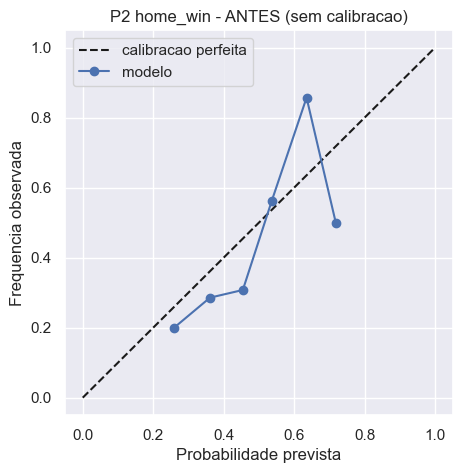

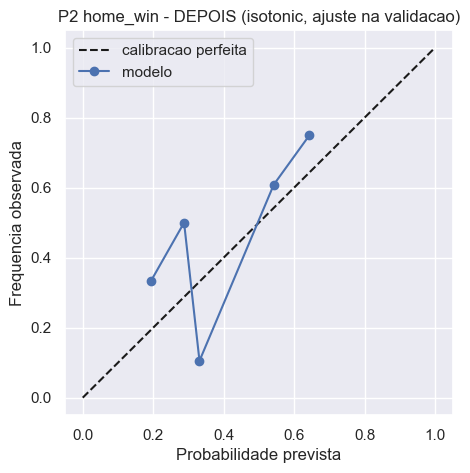

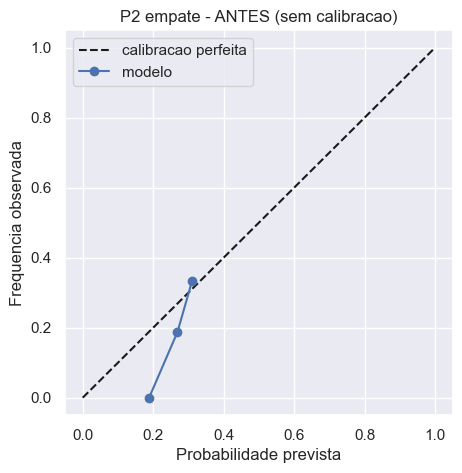

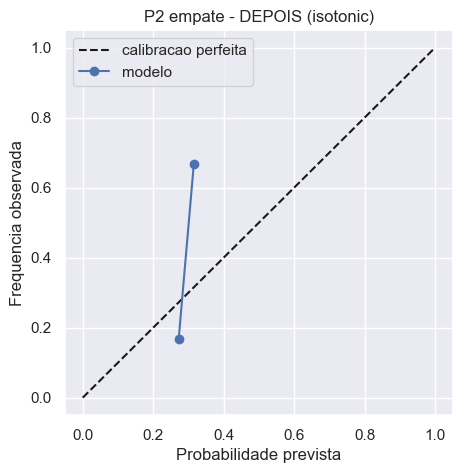

Reliability diagrams plotados (home_win e empate, antes vs. depois).
Obs.: com 57 jogos a curva e ruidosa; o ganho honesto esta nas
metricas proprias (RPS/log-loss/Brier) medidas no P5.1-P5.3.


In [38]:
# =====================================================================
# P5.4 - Reliability diagrams ANTES vs. DEPOIS da calibracao (criterio P5)
#   Reusa reliability_diagram do P1. Avaliamos no hold-out (visualizacao
#   ruidosa com 57 jogos) a classe home_win (0) e empate (1) - as mais
#   sensiveis. A curva deve aproximar da diagonal apos a calibracao.
# =====================================================================
reliability_diagram(p2_raw_probs, y_holdout, class_idx=0,
                    title="P2 home_win - ANTES (sem calibracao)")
reliability_diagram(p2_iso_probs, y_holdout, class_idx=0,
                    title="P2 home_win - DEPOIS (isotonic, ajuste na validacao)")
reliability_diagram(p2_raw_probs, y_holdout, class_idx=1,
                    title="P2 empate - ANTES (sem calibracao)")
reliability_diagram(p2_iso_probs, y_holdout, class_idx=1,
                    title="P2 empate - DEPOIS (isotonic)")
print("Reliability diagrams plotados (home_win e empate, antes vs. depois).")
print("Obs.: com 57 jogos a curva e ruidosa; o ganho honesto esta nas")
print("metricas proprias (RPS/log-loss/Brier) medidas no P5.1-P5.3.")


## **World Cup Predictions**
In this section we will read data from group stage matches and make predictions on the results.

In [39]:
# Importing the data to local notebook
df_qatar_world_cup = pd.read_csv(f'{RAW_DATA_DIR}/matches-schedule.csv')
df_qatar_world_cup.head()

,match,date,country1,country2,phase
0,1,11/06/2026,Mexico,South Africa,group matches
1,2,11/06/2026,South Korea,Czech Republic,group matches
2,3,12/06/2026,Canada,Bosnia and Herzegovina,group matches
3,4,12/06/2026,USA,Paraguay,group matches
4,5,13/06/2026,Qatar,Switzerland,group matches


In [40]:
# Keep only the columns consumed by the inference pipeline.
df_qatar_world_cup = df_qatar_world_cup.drop(
    columns=['phase', 'date', 'time_brasilia', 'timezone']
)

In [41]:
# Adjusting the name of the teams of Korea and Iran.
df_ranking = df_ranking.replace('Korea Republic', 'South Korea')
df_ranking = df_ranking.replace('IR Iran', 'Iran')

In [42]:
# Retrieving the latest FIFA ranking result for each football selection.
world_cup_rankings = df_ranking.loc[(df_ranking['rank_date'] == df_ranking['rank_date'].max()) & 
                                    df_ranking['country_full'].isin(df_qatar_world_cup['home'].unique())]

Pontos importantes da inferência (refatorada):

*   **Função única de features:** a Copa 2026 usa a **mesma** `build_football_features` do treino (sem train/serving skew).
*   **Modelo de produção (honesto):** o **1X2** vem do **Ensemble do modelo escolhido em P4.4 (`clf_prod`) + Dixon-Coles**. Como o P4 **não superou o P2 no hold-out**, `clf_prod` é o **P2 (só ranking)** → a saída efetiva é o **Ensemble P2+P3** (o melhor modelo honesto: RPS 0,2034). O **placar** vem da **matriz Dixon-Coles** em campo neutro (argmax — o P7.1 por pontos esperados foi testado e **rejeitado** no hold-out, ver `docs/AVALIACAO-PREVISOES-2026.md`).
*   **Campo neutro:** a Copa é em campo neutro → o mando (γ) é **zerado** (`neutral_game=True`).
*   **Alinhamento por nome:** as probabilidades são casadas aos jogos por **nome de seleção**, não por posição — corrige o bug em que probabilidades podiam ser atribuídas ao jogo errado.
*   **Fallback:** se uma seleção não estiver no ajuste do Dixon-Coles, a partida recai no `clf_prod` + heurística de placar.


In [ ]:
# Inferencia da Copa 2026 com a MESMA funcao de features do treino
# (build_football_features -> sem train/serving skew). O 1X2 vem do ENSEMBLE
# do modelo de producao com o Dixon-Coles (P3); o placar vem da matriz do
# Dixon-Coles em campo NEUTRO, com escala de gols P7.2 para o placar,
# condicionado ao resultado 1X2 do ensemble.
# Alinhamento por NOME (sem indexacao posicional).
# P5: o classificador 1X2 e a versao CALIBRADA escolhida em P5.3
# (clf_prod_calibrated / PROD_CALIB_FEATURES) - por padrao o P2 + isotonic,
# que melhora RPS/log-loss/Brier no hold-out sem violar a regra de ouro.
# Fallback compativel: se o P5 nao tiver rodado, usa clf_prod / PROD_FEATURES.

# (1) Ranking mais recente (rank + total_points) por selecao.
_latest_rank = df_ranking.loc[df_ranking.groupby('country_full')['rank_date'].idxmax()] \
                         .set_index('country_full')

# (2) Monta as partidas da Copa como linhas de historico (placar placeholder),
#     em NOME HISTORICO, preservando o nome de exibicao (disp_*) para a saida.
_NAME_FIX = {"South Korea": "Korea Republic", "Iran": "IR Iran"}
_sched_rows = []
for _match_order, (_match, _c1, _c2) in enumerate(df_qatar_world_cup.values):
    _h = _NAME_FIX.get(_c1, _c1); _a = _NAME_FIX.get(_c2, _c2)
    def _g(country, col):
        return _latest_rank.loc[country, col] if country in _latest_rank.index else np.nan
    _hr, _ar = _g(_c1, 'rank'), _g(_c2, 'rank')
    _hp, _ap = _g(_c1, 'total_points'), _g(_c2, 'total_points')
    _sched_rows.append(dict(
        date=pd.Timestamp('2026-06-11'), home_team=_h, away_team=_a,
        disp_home=_c1, disp_away=_c2, _match_order=_match_order,
        home_score=0, away_score=0, tournament=3, neutral=True,
        rank_home=_hr, rank_away=_ar, total_points_home=_hp, total_points_away=_ap,
        rank_difference=(_hr - _ar), average_rank=((_hr + _ar) / 2),
        score_difference=0, is_won=False, outcome=1, _sched=True))

_df_model_tag = df_model.copy(); _df_model_tag['_sched'] = False
_comb = pd.concat([_df_model_tag, pd.DataFrame(_sched_rows)], ignore_index=True)

# (3) MESMA funcao de features -> features pre-partida da Copa (estado do Elo
#     continua a serie de cada selecao). Recorta as linhas do calendario
#     e restaura a ordem original de matches-schedule.csv.
_feat_all, _ = build_football_features(_comb)
_inf = _feat_all[_feat_all['_sched'] == True].sort_values('_match_order').reset_index(drop=True)
# P5: usa o classificador CALIBRADO se o P5.3 foi executado; senao o do P4.
_PROD_CLF  = clf_prod_calibrated if 'clf_prod_calibrated' in dir() else clf_prod
_PROD_FEAT = PROD_CALIB_FEATURES if 'PROD_CALIB_FEATURES' in dir() else PROD_FEATURES
for _c in _PROD_FEAT:                           # imputa NaN (time sem historico)
    _inf[_c] = _inf[_c].fillna(train_feat[_c].median())

# Probabilidades 1X2 do modelo de producao (calibrado), alinhadas a _inf.
_prod_probs = proba_1x2(_PROD_CLF, _inf[_PROD_FEAT])

_rows = []
for _k, _r in enumerate(_inf.itertuples(index=False)):
    _h, _a = _r.home_team, _r.away_team
    _prod = _prod_probs[_k]
    if _h in team_idx and _a in team_idx:
        # 1X2: ensemble prod + DC cru. Placar: DC escalado e condicionado
        # ao resultado mais provavel do ensemble para evitar zebras artefatuais.
        _, _dc, _ = predict_match(
            dc_alpha, dc_beta, dc_gamma, dc_rho, _h, _a, neutral_game=True)
        _ens = (_prod + _dc) / 2; _ens = _ens / _ens.sum()
        p_home, p_draw, p_away = _ens

        _score_scale = GOAL_SCALE_PROD if 'GOAL_SCALE_PROD' in dir() else 1.0
        _lambda_k = LAMBDA_LAST10_K_PROD if 'LAMBDA_LAST10_K_PROD' in dir() else 0.0
        _lambda_clip = LAMBDA_LAST10_CLIP_PROD if 'LAMBDA_LAST10_CLIP_PROD' in dir() else (1.0, 1.0)
        _mh, _ma = _lambda_last10_mults(_r, k=_lambda_k, clip_bounds=_lambda_clip)
        _M_score, _, _ = predict_match(
            dc_alpha, dc_beta, dc_gamma, dc_rho, _h, _a, neutral_game=True,
            goal_scale=_score_scale, lambda_mult_home=_mh, lambda_mult_away=_ma)
        _draw_margin = DRAW_MARGIN_PROD if 'DRAW_MARGIN_PROD' in dir() else 0.0
        _score_outcome = choose_outcome_with_draw_margin(_ens, margin=_draw_margin)
        home_score, away_score = constrained_argmax_scoreline(_M_score, _score_outcome)
    else:
        # Fallback (selecao sem historico no DC): modelo de producao + heuristica.
        p_home, p_draw, p_away = _prod
        _o = int(np.argmax([p_home, p_draw, p_away])); home_score = away_score = 0
        if _o == 1:
            if max(p_home, p_away) > 0.30: home_score = away_score = 1
        elif _o == 0:
            home_score = 2 if p_home > 0.70 else 1; away_score = 1 if p_home <= 0.60 else 0
        else:
            away_score = 2 if p_away > 0.70 else 1; home_score = 1 if p_away <= 0.60 else 0
    _rows.append({"home": _r.disp_home, "home_score": int(home_score),
                  "away_score": int(away_score), "away": _r.disp_away})

predictions = pd.DataFrame(_rows, columns=["home", "home_score", "away_score", "away"])
print("Inferencia 2026: %d jogos. Modelo 1X2 = %s + Dixon-Coles; "
      "placar com goal_scale=%.2f, lambda_last10_k=%.2f, draw_margin=%.2f. "
      "Alinhamento por nome." % (len(predictions),
      PROD_CALIB_NAME if 'PROD_CALIB_NAME' in dir() else PROD_NAME,
      GOAL_SCALE_PROD if 'GOAL_SCALE_PROD' in dir() else 1.0,
      LAMBDA_LAST10_K_PROD if 'LAMBDA_LAST10_K_PROD' in dir() else 0.0,
      DRAW_MARGIN_PROD if 'DRAW_MARGIN_PROD' in dir() else 0.0))
predictions.head(12)


Por fim, o resultado da submissao e salvo localmente em `data/results/`.

In [ ]:
predictions.to_csv(f'{RESULTS_DIR}/predictions_submission.csv', index=False)

In [45]:
# ============================================================================
# P6 (item 5, opcional) - Teste de sanidade da validacao Copa 2022
# ----------------------------------------------------------------------------
# Recalcula o RPS do modelo de producao (Ensemble P2-iso + DC cru) no hold-out
# Copa 2022 e compara com o numero documentado em PLANO-MELHORIAS.md (~0.2013).
# Totalmente defensivo: so roda se as variaveis do pipeline ja existirem.
# ============================================================================
_REF_RPS_PROD = 0.2013   # Ensemble (P2-iso + DC cru), hold-out Copa 2022 (P5)
_TOL = 0.01
if all(_n in globals() for _n in ('evaluate_probs', 'ens_calib_probs', 'y_holdout')):
    _rps = evaluate_probs('Producao (Ensemble P2-iso + DC cru)',
                          ens_calib_probs, y_holdout)['RPS']
    _ok = abs(_rps - _REF_RPS_PROD) <= _TOL
    print('Sanity check Copa 2022: RPS=%.4f (ref=%.4f, tol=%.2f) -> %s'
          % (_rps, _REF_RPS_PROD, _TOL, 'PASS' if _ok else 'WARN: divergente'))
else:
    print('Sanity check ignorado: rode as celulas P1-P5 antes (variaveis ausentes).')

  Producao (Ensemble P2-iso + DC cru) RPS=0.2013  log_loss=0.9973  Brier=0.5854  acc1X2=0.561
Sanity check Copa 2022: RPS=0.2013 (ref=0.2013, tol=0.01) -> PASS
